# NHS GP Appointments: Capacity and Access

An analysis of NHS appointment records for England, August 2021 to June 2022,
examining whether the system had adequate capacity and how differently
Integrated Care Boards (ICBs) manage patient access.

Produced for the LSE Data Analytics Career Accelerator, Course 2: Data
Analytics using Python. Awarded a distinction.

**Datasets:** four were supplied; two were used. `national_categories` (nc) and
`appointments_regional` (ar) were analysed. `actual_duration` and a scraped
Twitter dataset were excluded, for reasons documented in section 1.

**Note on running this notebook:** the source data files are not included in
this repository (`national_categories.xlsx` alone runs to 817,394 rows). The
NHS appointment data is published openly by NHS Digital and is linked in the
README. All chart outputs are preserved below.

This is an extract from a longer working notebook, selected to show the
analytical reasoning rather than every step. Exploratory paths that led
nowhere have mostly been removed, but the ones that changed the conclusions
have been kept deliberately, including a measurement assumption that was
tested and overturned partway through.

**Use of AI:** the analytical questions, method decisions, interpretation and
findings are my own. AI assistance (Claude, Anthropic) was used to produce
code from that direction, to explain Python syntax and concepts, and to
troubleshoot errors during data import and execution. I am able to explain and
defend the technical content.

---
# 1. Datasets, sense-checks and exclusions

Each dataset was checked for structure, nulls, date coverage and plausible
ranges before any analysis. Two were excluded on quality grounds.

In [217]:
# Import the necessary libraries 
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Import the 2 csv NHS datasets
ad = pd.read_csv("actual_duration.csv")
ar = pd.read_csv('appointments_regional.csv')


In [218]:
# Import the largest NHS datset separately
nc = pd.read_excel('national_categories.xlsx')

## 1.1 Sense-check of dataset 1: actual_duration (ad)

**Source:** NHS GP appointment records  
**File:** actual_duration.csv  
**Size:** 137,793 rows, 8 columns  
**Date range:** 01-Dec-21 to 30-Jun-22 (7 months only)  
**Granularity:** Aggregated to one row per sub-ICB location + date + duration band combination  

### Structure
| Column | Type | Notes |
|--------|------|-------|
| sub_icb_location_code | object | Short code e.g. 00L |
| sub_icb_location_ons_code | object | ONS code e.g. E38000130 |
| sub_icb_location_name | object | Full name e.g. NHS North East and North Cumbria ICB code |
| icb_ons_code | object | Parent ICB level |
| region_ons_code | object | Region level |
| appointment_date | object | String format dd-Mon-yy — converted |
| actual_duration | object | Duration band as string — needs converting |
| count_of_appointments | int64 | Aggregated count, not individual records |

### Key observations
- Data is NOT one row per appointment but aggregated by location + date + duration band
- appointment_date stored as string (dd-Mon-yy). Converted to datetime.
- actual_duration stored as unequal bands (e.g. 1-5 mins, 6-10 mins, 11-15 mins, 16-20 mins, 21-30 mins, 31-60
  mins). Use midpoints?. See recommendations.
- No missing values (all 137,793 rows complete across all columns)
- count_of_appointments is an estimate

### Data quality concerns
- Only 7 months of data (Dec-21 to Jun-22). ar and nc include these dates. (See date alignment above).
-  "Unknown / Data Quality" is the second largest group in head output. 15 % of total appointments.

### To do/Watch out for
- Don't treat count_of_appointments as a row count
- Duration bands can't be averaged directly. Decide how to handle these (midpoint? exclude unknowns?)
- Reorder time bands chronologically before any time-series analysis on these fields in ad and ar.
- What % of total appointments fall in "Unknown / Data Quality"?


In [4]:
# 1.1 Sense-check the actual_duration.csv data (ad)
# View the DataFrame (structure, types, nulls, numeric ranges, sample rows)
#1.1.1
ad.info()        # structure, types, nulls


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


**Observations ** No missing values **Dates and durations stored as strings

In [5]:
# 1.1.2
ad.describe()    # numeric ranges

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


**Observation: Max row count includes 15,400 appointments in one day, for one sub-ICB location, within one duration band. Investigate.

In [6]:
# 1.1.3 Investigate max row details:
ad[ad['count_of_appointments'] == ad['count_of_appointments'].max()]

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
125518,A3A8R,E38000255,NHS North East London ICB - A3A8R,E54000029,E40000003,17-Jan-22,Unknown / Data Quality,15400


In [7]:
# 1.1.4
ad.head()        # sense check top

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


** Observations
** Durations stored in unequal bands
** Counts are aggregated  ** Unknown observation second largest group in this listing

## 1.2 Sense-check of dataset 2: appointments_regional (ar)

**Source:** NHS GP appointment records regional

**File:** appointments_regional.csv

**Size:** 596,821 rows, 7 columns

**Date range:** Jan 2020 to Jun 2022 (30 months full reporting period)

**Granularity:** Aggregated to one row per ICB + month + appointment_status + hcp_type + appointment_mode + time_between_book_and_appointment combination

### Structure
| Column | Type | Notes |
|--------|------|-------|
| icb_ons_code | object | ICB level only — less granular than ad |
| appointment_month | object | String format YYYY-MM, needs converting |
| appointment_status | object | e.g. Attended, DNA, Unknown |
| hcp_type | object | GP or Other Practice Staff |
| appointment_mode | object | e.g. Face-to-Face, Telephone, Unknown |
| time_between_book_and_appointment | object | Banded e.g. Same Day, 1 Day, 2-7 Days |
| count_of_appointments | int64 | Estimated count, see top-level data quality notes |

### Key observations
- No missing values across all 596,821 rows
- More rows than ad (596,821 vs 137,793) but less geographic granularity: ICB level only, no sub-ICB
- Contains columns not in ad: appointment_status, hcp_type, appointment_mode, time_between_book_and_appointment
- appointment_month stored as string (YYYY-MM) - different format from ad's appointment_date (dd-Mon-yy) - needs to be converted.
- time_between_book_and_appointment uses unequal bands, not directly comparable numerically
- Distribution skews heavily right: median 47, mean 1,245, max 211,265

### Data quality concerns
- tail() shows simultaneous Unknown values across appointment_status, hcp_type and appointment_mode in same rows: likely Cegedim practices (see top-level notes)

### Max row details
- Row 144,544: ICB E54000027, January 2020, Attended, GP, Face-to-Face, Same Day — 211,265 appointments
- **Explanation:** Pre-Covid January peak flu season — plausible reason for highest count

### Possible join key with ad
- icb_ons_code (present in both) — to be confirmed

### Analytical questions to investigate
- Did F2F same-day GP appointments ever recover to pre-Covid (Jan 2020) levels? Check Winter 2021/22 data
- What factors characterise appointment groups with 7 or fewer appointments (1st quartile)?
- Both ad and ar skew right. Compare largest groups across datasets to identify key drivers of demand.

In [9]:
# Sense-check the appointments_regional.csv data set (ar).
# View the DataFrame (structure, types, nulls, numeric ranges, sample rows)
# 1.2.1 structure, types, nulls
ar.info()        


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


** Observations ** No missing values ** Times and months stored as strings ** Less granular data than ad but additional detail (mode and hcp) and many more rows

## 1.3 Sense-check of dataset 3: national_categories (nc)

**Source:** National categories of care logged by GP practices.

**File:** national_categories.xlsx

**Size:**   817394 rows,  8 columns

**Date range:** Aug-21 to Jun-22 (11 months)

**Granularity:** Aggregated to one row per day + sub ICB + service setting + context type + national category 

### Structure
| Column | Type | Notes |
|--------|------|-------|
| appointment_date | datetime | YYYY-MM-DD 00:00:00.  ar has daily dates but doesn't include hrs:mins:secs.      
| icb_ons_code | object | ICB level only. ar only has this high level  |               
| sub_icb_location_name | object | Full name e.g. NHS North East and North Cumbria ICB-00L |     
| service_setting | object |5: General Practice, Primary Care Network, Extended Access Provision, Other and Unmapped |    
| context_type | object | 3: care-related encounter, unmapped and inconsistent mapping (see metadata) |    
| national_category | object | 18 incl. planned/ unplanned clinical activity, general consultation acute/routine, home visit |   
| count_of_appointments | integer | Estimates. See top-level note.|         
| appointment_month | object | String format YYYY-MM — needs converting |

### Key observations
- No missing values across all 817,394 rows
- More rows than ar (596,821) or ad (137,793) but rows are aggregated.
- Sub_ICB level
- Contains columns not in other datasets: 
- appointment_month and appointment_date (dd-Mon-yy hr:min:sec) both stored in datetime
- Distribution skews heavily right: median 25, mean 362, max 16590


### Analytical questions to investigate

- What factors charcterise largest appointment groups in each dataset (to identify key drivers of demand).
  

In [14]:
# Import and sense-check the national_categories.xlsx data set as nc.
# View the DataFrame (structure, types, nulls, numeric ranges, sample rows)
# 1.3.1 structure, types, nulls
nc.info()        

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


**Observations *No missing values *appointment_date in datetime format. *appointment_month stored as string 
**icb_ons_code join to ad and ar **appt month joins to ar *Location name joins to ad; appt date includes time so doesn't join to as
*Compare dates covered in each for overlap


In [15]:
# 1.3.2 numeric ranges
nc.describe()   

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


## 1.4 External data: the Twitter dataset

The brief asked what external data could add to the appointment records. The
supplied Twitter dataset was examined and rejected.

In [103]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [104]:
# Load the Twitter dataset
tweets = pd.read_csv('tweets.csv')

# Explore the metadata
print("Shape:", tweets.shape)
print("\nColumns:", tweets.columns.tolist())
print("\nData types:")
print(tweets.dtypes)

# View the DataFrame.


Shape: (1174, 10)

Columns: ['tweet_id', 'tweet_full_text', 'tweet_entities', 'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count', 'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted', 'tweet_lang']

Data types:
tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count         int64
tweet_favorite_count        int64
tweet_favorited              bool
tweet_retweeted              bool
tweet_lang                 object
dtype: object


**Observation:** From the first 5 entries, it is clear that these tweets include comments and opinions about healthcare in countries other than England.

In [106]:
# Explore the metadata
print(tweets.info())
print(tweets.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None
           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std

**Observations:**
1,174 tweets across 10 columns. Two engagement metrics (retweet_count and favorite_count) are integer types so can be sorted. 
Further investigation required to assess how many refer to the NHS.


In [109]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtag_counts = pd.Series(hashtags).value_counts().reset_index()

# Rename the columns.
hashtag_counts.columns = ['hashtag', 'count']

# View the DataFrame.
hashtag_counts.head(10)

# Rename the columns.


,hashtag,count
0,#healthcare,835
1,#health,85
2,#ai,46
3,#medicine,42
4,#job,38
5,#medical,35
6,#digitalhealth,31
7,#strategy,30
8,#pharmaceutical,28
9,#medtwitter,27


In [112]:
# Display records where the count is larger than 10.
popular_hashtags = hashtag_counts[hashtag_counts['count'] > 10]
popular_hashtags

,hashtag,count
0,#healthcare,835
1,#health,85
2,#ai,46
3,#medicine,42
4,#job,38
...,...,...
44,#innovation,11
45,#usa,11
46,#digitaltransformation,11
47,#healthcareit,11


**Observations:** Surprising to see AI and Jobs in the top 5 and disappointing not to see #NHS,  
#gpappointments, #gpwaitingtimes. This adds further weight to the hypothesis that the dataset will  
be of limited relevance to the analysis.

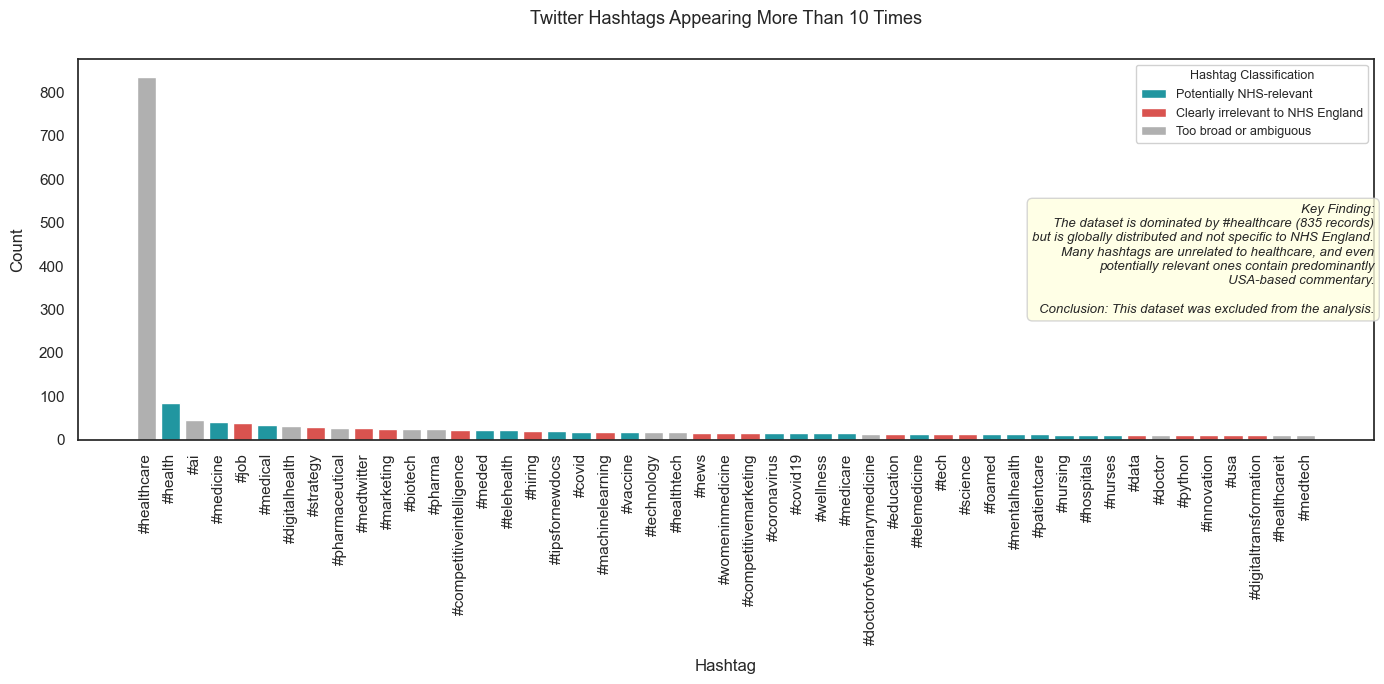

In [209]:
# CHART 1: The Limitations of External Data Sources

# Classify hashtags by relevance to NHS England analysis
nhs_relevant = [
    '#health', '#medicine', '#medical', '#covid', '#covid19',
    '#coronavirus', '#nursing', '#hospitals', '#nurses',
    '#mentalhealth', '#patientcare', '#vaccine', '#foamed',
    '#tipsfornewdocs', '#meded', '#telehealth', '#telemedicine',
    '#wellness', '#medicare'
]

clearly_irrelevant = [
    '#job', '#marketing', '#hiring', '#competitivemarketing',
    '#usa', '#womeninmedicine', '#python', '#medtwitter',
    '#competitiveintelligence', '#strategy', '#news',
    '#digitaltransformation', '#innovation', '#data',
    '#science', '#tech', '#education', '#machinelearning'
]

def get_colour(hashtag):
    if hashtag in nhs_relevant:
        return '#2196a0'
    elif hashtag in clearly_irrelevant:
        return '#d9534f'
    else:
        return '#b0b0b0'

colours = [get_colour(h) for h in popular_hashtags['hashtag']]

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(popular_hashtags['hashtag'],
       popular_hashtags['count'],
       color=colours,
       edgecolor='white')

ax.set_title('Twitter Hashtags Appearing More Than 10 Times\n',
             fontsize=13, pad=10)
ax.set_xlabel('Hashtag', labelpad=10)
ax.set_ylabel('Count', labelpad=10)
ax.tick_params(axis='x', rotation=90)

# Legend with annotation below it, positioned in white space
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196a0', label='Potentially NHS-relevant'),
    Patch(facecolor='#d9534f', label='Clearly irrelevant to NHS England'),
    Patch(facecolor='#b0b0b0', label='Too broad or ambiguous')
]

legend = ax.legend(handles=legend_elements,
                   loc='upper right',
                   framealpha=0.9,
                   fontsize=9,
                   title='Hashtag Classification',
                   title_fontsize=9)

# Annotation in axes coordinates, below legend in white space
ax.annotate(
    'Key Finding:\n'
    'The dataset is dominated by #healthcare (835 records)\n'
    'but is globally distributed and not specific to NHS England.\n'
    'Many hashtags are unrelated to healthcare, and even\n'
    'potentially relevant ones contain predominantly\n'
    'USA-based commentary.\n\n'
    'Conclusion: This dataset was excluded from the analysis.',
    xy=(1.0, 0.62),
    xycoords='axes fraction',
    fontsize=9.5,
    style='italic',
    va='top',
    ha='right',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow',
              edgecolor='#cccccc',
              alpha=0.8)
)

plt.tight_layout()
plt.show()

## Key Finding  

This data is too unreliable to be of analytical use. Many of the top hashtags listed in the chart clearly have nothing to do with healthcare, and initial exploration of those that do reveals that much of the content is from commentators in the USA, speaking about a different healthcare system. 

## Conclusion  

Exclude this dataset from the analysis.

---
# 2. National capacity utilisation

The NHS publishes a benchmark of 1.2 million appointments per day nationally.
Measuring utilisation against it requires deciding how many days in a month
GP practices actually work — and that decision turns out to drive the answer.

In [114]:
# Prepare your workstation.
# Load the appointments_regional.csv file.
ar = pd.read_csv('appointments_regional.csv')
# View the DataFrame.
print(ar.shape)
ar.head()



(596821, 7)


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [115]:
# Print the min and max dates.
print(ar["appointment_month"].min())
print(ar["appointment_month"].max())

2020-01
2022-06


**Observation:** This dataset spans 30 months, while nc covers only the 11 month period from August 2021 to June 2022. Create a subset for the matching dates so that cross dataset comparisons can be made.
    

In [116]:
# Filter the data set to only look at data from 2021-08 onwards.
ar_2021 = ar[ar['appointment_month'] >= '2021-08']
print(ar_2021.shape)
print(ar_2021['appointment_month'].min())
print(ar_2021['appointment_month'].max())

(223418, 7)
2021-08
2022-06


**Observation:** The row count has reduced from almost 600,000 to just over 220,000 as expected.

## 2.1 Measuring against the national benchmark

**Analytical question:** Has there been adequate staff and capacity in the networks? 

In [117]:
# Create an aggregated data set to review the different features.
# Create a new DataFrame (e.g. ar_agg) to review the different features.
# Ensure to include the columns appointment_month, hcp_type, appointment_status, appointment_mode, and time_between_book_and_appointment.
# Use the groupby() function, and calculate the sum of count_of_appointments. Remember to reset the index.

ar_agg = ar_2021.groupby([
    'appointment_month',
     'icb_ons_code', 
    'appointment_status',
    'appointment_mode', 'hcp_type',
    'time_between_book_and_appointment', 
])['count_of_appointments'].sum().reset_index()

print(ar_agg.shape)
ar_agg.head()
# View the DataFrame.


(108978, 7)


,appointment_month,icb_ons_code,appointment_status,appointment_mode,hcp_type,time_between_book_and_appointment,count_of_appointments
0,2021-08,E54000008,Attended,Face-to-Face,GP,1 Day,28360
1,2021-08,E54000008,Attended,Face-to-Face,GP,15 to 21 Days,6345
2,2021-08,E54000008,Attended,Face-to-Face,GP,2 to 7 Days,45744
3,2021-08,E54000008,Attended,Face-to-Face,GP,22 to 28 Days,3061
4,2021-08,E54000008,Attended,Face-to-Face,GP,8 to 14 Days,14940


**Observation:** The reduction in row count from 223,418 to 108,978 after this aggregation step is plausible. There are 42 ICBs in England and 106 sub-ICBs. The original dataset was compiled from data provided by GPs and would have originally been aggregated to sub ICB level. As a result, when rolled up to ICB level (as ar has been), it is expected that common combinations of appointments (eg GP, face-to-face, 1 day between booking and appointment, January 2022) had duplicate entries within each ICB and these have now been aggregated, while rarer appointment type combinations (eg unusual modes, long lead times and/or data quality issues) are less likely to have a duplicate row within their ICB. The row count has fallen substantially but not in direct proportion to the 42/106 rate.

In [118]:
# Determine the total number of appointments per month
ar_df = ar_2021.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add utilisation column — monthly total divided by 30 for daily average
ar_df['utilisation'] = (ar_df['count_of_appointments'] / 30).round(1)

# Convert appointment_month to string for visualisation
ar_df['appointment_month'] = ar_df['appointment_month'].astype(str)
ar_agg['appointment_month'] = ar_agg['appointment_month'].astype(str)


# View the DataFrame.
print(ar_df)


   appointment_month  count_of_appointments  utilisation
0            2021-08               23852171     795072.4
1            2021-09               28522501     950750.0
2            2021-10               30303834    1010127.8
3            2021-11               30405070    1013502.3
4            2021-12               25140776     838025.9
5            2022-01               25635474     854515.8
6            2022-02               25355260     845175.3
7            2022-03               29595038     986501.3
8            2022-04               23913060     797102.0
9            2022-05               27495508     916516.9
10           2022-06               25828078     860935.9


**Observation:** The count of appointments and utilisation both peak in October and November 2021. This is currently assumed to be in part due to a planned catch-up on postponed routine and pre-surgical appointments in this post-lockdown/ post-holiday period. Further investigation required.

In [119]:
# Rerun the above query with an additional column to calcuate the utilisation rate in order to assess capacity.
ar_df['utilisation_rate'] = (ar_df['utilisation'] / 1200000 * 100).round(1)
print(ar_df)

   appointment_month  count_of_appointments  utilisation  utilisation_rate
0            2021-08               23852171     795072.4              66.3
1            2021-09               28522501     950750.0              79.2
2            2021-10               30303834    1010127.8              84.2
3            2021-11               30405070    1013502.3              84.5
4            2021-12               25140776     838025.9              69.8
5            2022-01               25635474     854515.8              71.2
6            2022-02               25355260     845175.3              70.4
7            2022-03               29595038     986501.3              82.2
8            2022-04               23913060     797102.0              66.4
9            2022-05               27495508     916516.9              76.4
10           2022-06               25828078     860935.9              71.7


## Key Findings

> **Superseded.** This finding rests on a 30-calendar-day denominator, replaced later in this section. See *section 2.2*.

**Utilisation of services never exceeds 84%** This tells us that, at a national aggregated level, the system is not exceeding NHS stated capacity levels. Note

**Caveats**
1. These are monthly averages which hide daily peaks and troughs in which the stated capacity may have been exceeded.
2. These are aggregated at ICB level, but there is likely to be considerable variation in appointment rates at sub ICB level.
3. The appointments are averaged over 30 days per month whereas most GP practices are unlikely to have been offering appointments on Sundays, and perhaps not on Saturdays, even in this post-COVID period.
4. The utilisation rate includes DNA appointments, overstating productive use of capacity. Excluding DNAs would reduce the utilisation rate however DNA slots cannot be reallocated in real time, meaning the capacity loss is real even though it inflates the utilisation figure.

**To do:**
Quantify the scale of DNA waste.


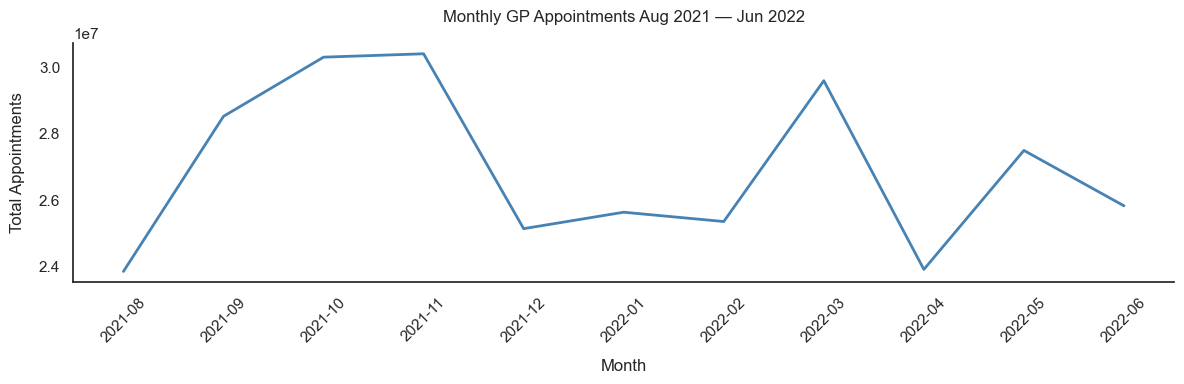

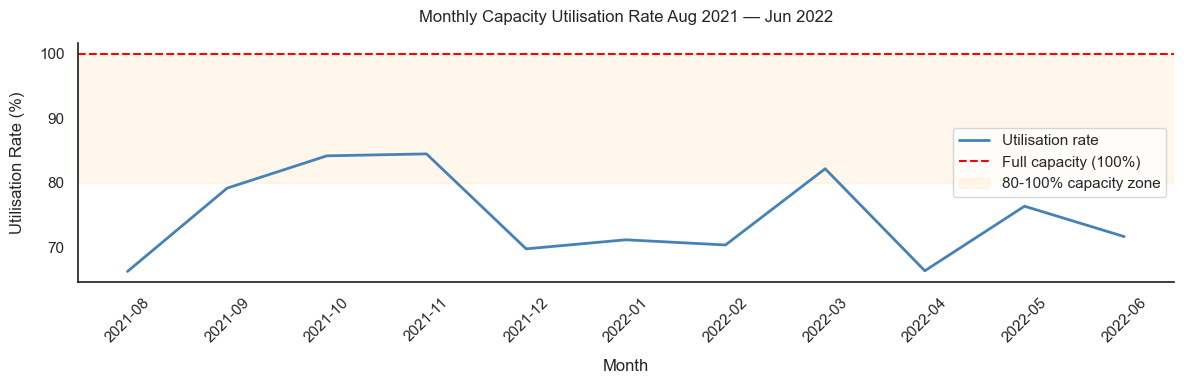

In [120]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
# Create a lineplot with Seaborn.

# Plot 1: Monthly appointment counts
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=ar_df, x='appointment_month', 
             y='count_of_appointments', ax=ax,
             color='steelblue', linewidth=2)
ax.set_title('Monthly GP Appointments Aug 2021 — Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Total Appointments', labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
sns.despine()
plt.show()

# Plot 2: monthly capacity utilisation (utilisation rate vs 100% capacity benchmark)
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=ar_df, x='appointment_month',
             y='utilisation_rate', ax=ax,
             color='steelblue', linewidth=2, label='Utilisation rate')
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.08, color='orange',
           label='80-100% capacity zone')
ax.set_title('Monthly Capacity Utilisation Rate Aug 2021 — Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()



**Observations:**

1. The lines on the two charts have a similar shape because the second one is simply a rescaled version of the first, however the second chart is more meaningful because we can easily see how rarely appointments exceed even 80% of stated capacity, however, as stated above, this needs to be investigated at a more granular level.

2. The October/November peak fits my hypothesis about post-lockdown catch-up.

3. The March 2022 secondary peak may reflect the end of the Omicron wave and a surge in patients who had been avoiding services.

4. The sudden dip in April 2022 is marked. This could be a combination of Easter holidays and the end of the catch-up surge.


**To do:**
1. Check the data for the previous 12 months to see if similar seasonal trends are evident.
2. Look at appointment counts in the nc dataset. Check for similar national trends and drill down to sub ICB and weekly/daily appointments,



   appointment_month  count_of_appointments  utilisation_rate
0            2020-01               27199296              75.6
1            2020-02               24104621              67.0
2            2020-03               24053468              66.8
3            2020-04               16007881              44.5
4            2020-05               16417212              45.6
..               ...                    ...               ...
25           2022-02               25355260              70.4
26           2022-03               29595038              82.2
27           2022-04               23913060              66.4
28           2022-05               27495508              76.4
29           2022-06               25828078              71.7

[30 rows x 3 columns]


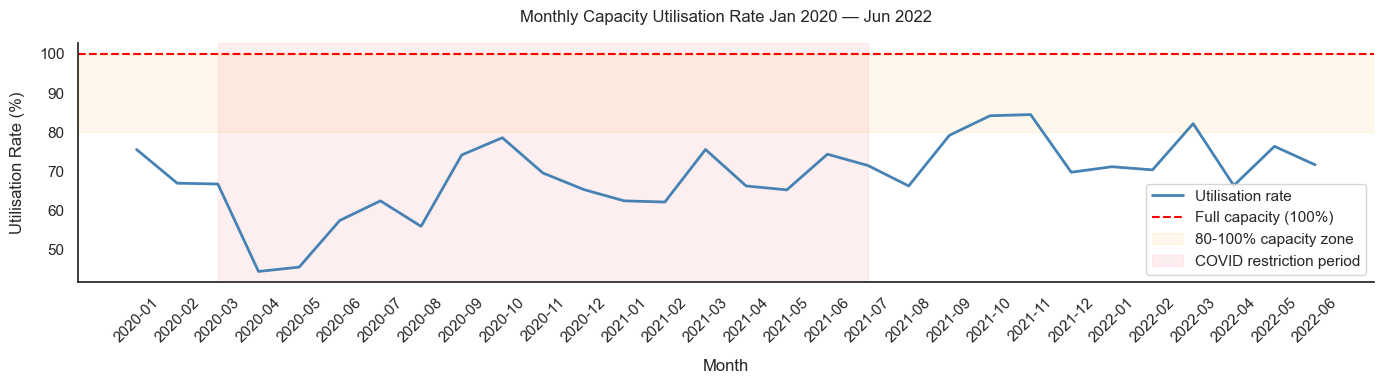

In [121]:
# Rerun the above query using the original full date range to establish to what extent the shape of the line plot represents seasonal trends.
# Temporary - full date range for seasonal comparison
ar_df_full = ar.groupby('appointment_month')['count_of_appointments'].sum().reset_index()
ar_df_full['utilisation_rate'] = (ar_df_full['count_of_appointments'] / 30 / 1200000 * 100).round(1)
ar_df_full['appointment_month'] = ar_df_full['appointment_month'].astype(str)

print(ar_df_full)

# Plot full date range
fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(data=ar_df_full, x='appointment_month',
             y='utilisation_rate', ax=ax,
             color='steelblue', linewidth=2, label='Utilisation rate')
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.08, color='orange',
           label='80-100% capacity zone')
ax.axvspan('2020-03', '2021-07',
           alpha=0.12, color='lightcoral',
           label='COVID restriction period')
ax.set_title('Monthly Capacity Utilisation Rate Jan 2020 — Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()

**Observations:** 

1. It is clear from this line plot that appointments over this period have been markedly affected by COVID surges and lockdowns.
   Seasonal patterns are partially visible but the data doesn't allow us to distinguish confidently between seasonal patterns and COVID effects. This has
   implications for any recommendations to the NHS about demand and capacity going forward since we are unable to compare the data to a "normal" time period.

2. An October peak appears in both 2020 and 2021, suggesting it may be a genuine seasonal pattern rather than purely a COVID catch-up effect. Similarly
   December/January dips appear in both years, but these must be viewed as no more than tentative evidence of seasonality due to COVID disruptions.

3. The sharpest drop over the period is in April 2020 (the first national lockdown) when utilisation rates fell to around 44%. The recovery from there is
   gradual and doesn't return to the pre-COVID January/February level until late 2021.

## Key Observation
The figures look wrong. It seems highly unlikely that the NHS was not working at capacity during this period. The 30-working-days-a-month figure grossly overstates the true number of days when a GP surgery is open. Redo the above calculations dividing by 24 working days a month instead of 30.


In [122]:
# Change the calculation from 30 calendar days to 24 workings days (a more realistic calculation) 
#and compare this new average to the 1.2 million capacity figure.

ar_df['utilisation_rate_24'] = (
    ar_df['count_of_appointments'] / 24 / 1200000 * 100
).round(1)

print(ar_df[['appointment_month', 'utilisation_rate', 'utilisation_rate_24']])

   appointment_month  utilisation_rate  utilisation_rate_24
0            2021-08              66.3                 82.8
1            2021-09              79.2                 99.0
2            2021-10              84.2                105.2
3            2021-11              84.5                105.6
4            2021-12              69.8                 87.3
5            2022-01              71.2                 89.0
6            2022-02              70.4                 88.0
7            2022-03              82.2                102.8
8            2022-04              66.4                 83.0
9            2022-05              76.4                 95.5
10           2022-06              71.7                 89.7


**Observations:**
This chart paints a very different picture of capacity. In three of the 11 months, the average number of booked appointments exceeds the stated maximum capacity and in every month, the national figure exceeds 80% capacity without drilling down to look for regional differences (eg in densely populated inner city locations).


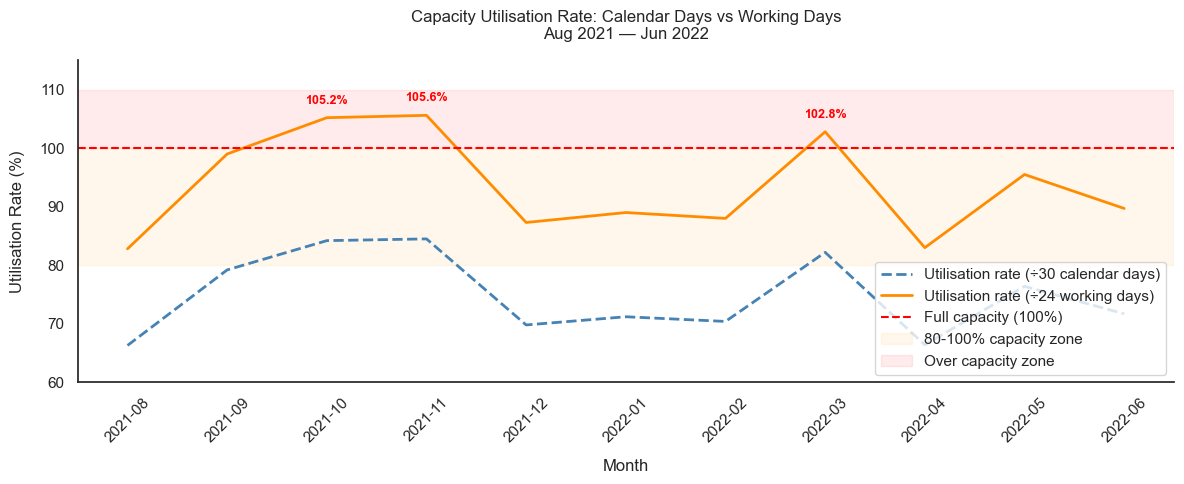

In [123]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot both utilisation rates
ax.plot(ar_df['appointment_month'], ar_df['utilisation_rate'],
        color='steelblue', linewidth=2, linestyle='--',
        label='Utilisation rate (÷30 calendar days)')

ax.plot(ar_df['appointment_month'], ar_df['utilisation_rate_24'],
        color='darkorange', linewidth=2,
        label='Utilisation rate (÷24 working days)')

# Reference lines
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.08, color='orange',
           label='80-100% capacity zone')
ax.axhspan(100, 110, alpha=0.08, color='red',
           label='Over capacity zone')

# Annotate the months that exceed 100%
for idx, row in ar_df[ar_df['utilisation_rate_24'] >= 100].iterrows():
    ax.annotate(f"{row['utilisation_rate_24']}%",
                xy=(row['appointment_month'], row['utilisation_rate_24']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='red', fontweight='bold')

ax.set_title('Capacity Utilisation Rate: Calendar Days vs Working Days\nAug 2021 — Jun 2022',
             pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
ax.set_ylim(60, 115)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
sns.despine()
plt.show()

In [124]:
# Try a third, more nuanced approach using 5.5/7 to simulate Mon-Fri plus Saturday morning surgeries

# Import a calendar to find the exact number of days in each month 
import calendar
# Slice by the first 4 digits (the year) and by digits 5 and 6 (the month)
# Use the monthrange method which creates tuple pairs to simultaneously calculate:
# (a) the first day of the month and (b) the number of working days in that month
# The first day of the month is needed for the calculation but not for the output (position 0 in the pair)
# so we call only the second item in the tuple pair (ie the number of working days) 
# by adding the [1] at the end (ie just use the item in the second position)

ar_df['days_in_month'] = ar_df['appointment_month'].apply(
    lambda x: calendar.monthrange(int(x[:4]), int(x[5:7]))[1]
)

# Calculate the number of working days using 5.5/7 assumption
ar_df['working_days_55'] = (ar_df['days_in_month'] * 5.5 / 7).round(1)

# Calculate a more accurate utilisation rate using 5.5/7
# Divide total monthly appointments by working days to find the average daily appointments
# Divide by 1.2M to calculate the proportion of daily capacity used
# Multiply by 100 to express this as a percentage

ar_df['utilisation_rate_55'] = (
    ar_df['count_of_appointments'] / 
    ar_df['working_days_55'] / 
    1200000 * 100
).round(1)

print(ar_df[['appointment_month', 'days_in_month', 
             'working_days_55', 'utilisation_rate',
             'utilisation_rate_24', 'utilisation_rate_55']])

   appointment_month  days_in_month  working_days_55  utilisation_rate  \
0            2021-08             31             24.4              66.3   
1            2021-09             30             23.6              79.2   
2            2021-10             31             24.4              84.2   
3            2021-11             30             23.6              84.5   
4            2021-12             31             24.4              69.8   
5            2022-01             31             24.4              71.2   
6            2022-02             28             22.0              70.4   
7            2022-03             31             24.4              82.2   
8            2022-04             30             23.6              66.4   
9            2022-05             31             24.4              76.4   
10           2022-06             30             23.6              71.7   

    utilisation_rate_24  utilisation_rate_55  
0                  82.8                 81.5  
1                

### Key findings based on 3 different measures of the utilisation of services against a given max capacity rate

> **Note.** The 5.5-day assumption used below was subsequently tested against the data and revised to 5 days. Figures in this cell are superseded by the corrected analysis that follows.

**The conservative measure (/30):**
This measure grossly understates the utilisation of services because there are never 30 working GP days in a calendar month.
The peak month is stated as using only 84.5% of capacity. This seems counter-intuitive given the reported pressures on the NHS during this post-COVID period. 

**The middle range (/24):**
Using 24 as a simple count of days, three months show as having operated over-capacity and the peak rate is 105.6% in November. This is likely closer to reality but it's still a very crude measure given the variance in working days from month to month.

**The refined measure (5.5/7):**
The results from this third chart show that the NHS nationally was working beyond capacity in 4 of these months.
This is the most accurate of the three measures because it applies a 5.5-day working week assumption to the exact number of days in each calendar month, rather than using a fixed divisor. This accounts for the natural variation in month length which the cruder methods ignore.  The improved accuracy of these figures can be seen by comparing changes in individual months across the three calculations:  

-The November rate has climbed from 84.5% to 105.6% and then again to 107.4% (because November only has 30 days).  

-The February rate has jumped from 66.4% in the first calculation to 88% and then to 96% because it only has 28 days.




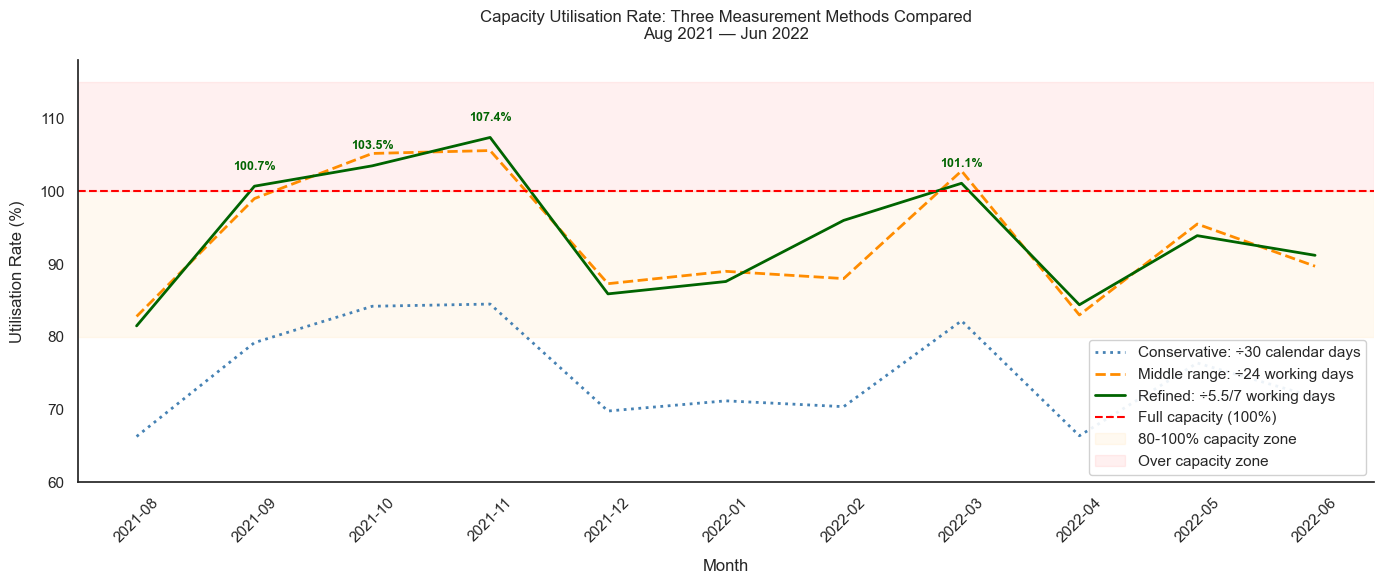

In [125]:
# Plot the three different capacity measures in one chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot all three utilisation rates
ax.plot(ar_df['appointment_month'], ar_df['utilisation_rate'],
        color='steelblue', linewidth=2, linestyle=':',
        label='Conservative: ÷30 calendar days')

ax.plot(ar_df['appointment_month'], ar_df['utilisation_rate_24'],
        color='darkorange', linewidth=2, linestyle='--',
        label='Middle range: ÷24 working days')

ax.plot(ar_df['appointment_month'], ar_df['utilisation_rate_55'],
        color='darkgreen', linewidth=2, linestyle='-',
        label='Refined: ÷5.5/7 working days')

# Reference lines and shading
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.06, color='orange',
           label='80-100% capacity zone')
ax.axhspan(100, 115, alpha=0.06, color='red',
           label='Over capacity zone')

# Annotate over-capacity points on the refined measure only
for idx, row in ar_df[ar_df['utilisation_rate_55'] >= 100].iterrows():
    ax.annotate(f"{row['utilisation_rate_55']}%",
                xy=(row['appointment_month'], row['utilisation_rate_55']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9,
                color='darkgreen', fontweight='bold')

ax.set_title('Capacity Utilisation Rate: Three Measurement Methods Compared\n'
             'Aug 2021 — Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
ax.set_ylim(60, 118)
plt.xticks(rotation=45)
plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
sns.despine()
plt.show()

**Observations:** This chart shows clearly how the different measurements of capacity utilisation change the story and highlight the importance of defining the best metrics in any measurement. 

**Next steps:**
The 5.5 days a week line will be used to sample results from the five largest sub ICBs by count of appointments 

## 2.2 Testing the working-week assumption

The 5.5-day assumption above was an estimate. Before relying on it, it was
tested against the data.

  day_of_week  count_of_appointments   pct
0      Monday               59695267  20.2
1     Tuesday               61806933  20.9
2   Wednesday               58984265  19.9
3    Thursday               56976354  19.2
4      Friday               52394868  17.7
5    Saturday                5574922   1.9
6      Sunday                 614161   0.2


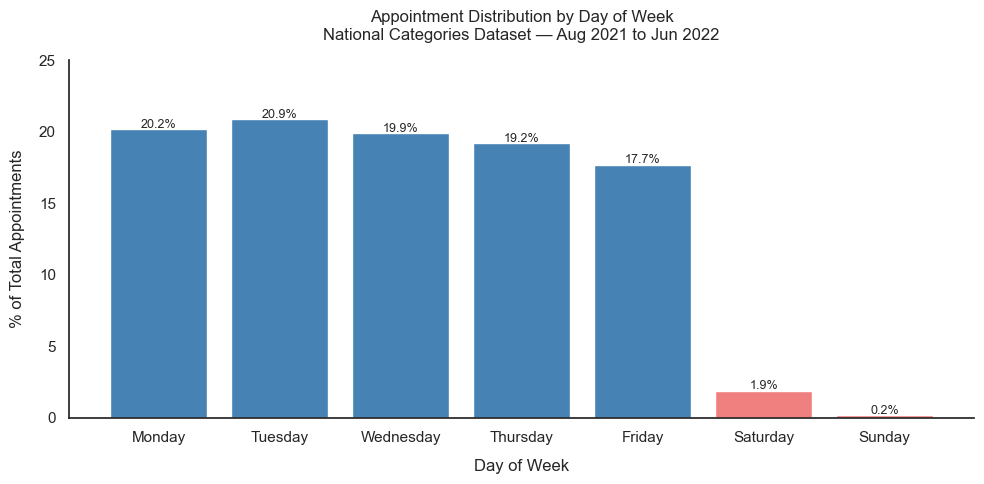

In [191]:
# Chart 3: Mon-Fri is the working week in GP surgeries

# Check appointment distribution by day of week from nc
nc['day_of_week'] = pd.to_datetime(nc['appointment_date']).dt.day_name()

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_volumes = (nc.groupby('day_of_week')['count_of_appointments']
               .sum()
               .reindex(dow_order)
               .reset_index())

dow_volumes['pct'] = (dow_volumes['count_of_appointments'] / 
                      dow_volumes['count_of_appointments'].sum() * 100).round(1)

print(dow_volumes.to_string())
# Bar chart of appointment distribution by day of week
fig, ax = plt.subplots(figsize=(10, 5))

colours = ['steelblue' if day != 'Saturday' and day != 'Sunday' 
           else 'lightcoral' 
           for day in dow_volumes['day_of_week']]

ax.bar(dow_volumes['day_of_week'], 
       dow_volumes['pct'],
       color=colours, edgecolor='white')

# Annotate bars with percentages
for i, row in dow_volumes.iterrows():
    ax.text(i, row['pct'] + 0.1, f"{row['pct']}%",
            ha='center', fontsize=9)

ax.set_title('Appointment Distribution by Day of Week\n'
             'National Categories Dataset — Aug 2021 to Jun 2022',
             pad=15)
ax.set_xlabel('Day of Week', labelpad=10)
ax.set_ylabel('% of Total Appointments', labelpad=10)
ax.set_ylim(0, 25)
plt.tight_layout()
sns.despine()
plt.show()

In [192]:
# Where do Saturday appointments come from?
sat = nc[pd.to_datetime(nc['appointment_date']).dt.day_name() == 'Saturday']
print(sat.groupby('service_setting')['count_of_appointments'].sum().sort_values(ascending=False))
print()
print(sat.groupby('national_category')['count_of_appointments'].sum().sort_values(ascending=False).head(10))


service_setting
General Practice             4856121
Unmapped                      253153
Primary Care Network          178744
Extended Access Provision     173617
Other                         113287
Name: count_of_appointments, dtype: int64

national_category
Planned Clinical Procedure                                   2152036
General Consultation Routine                                 1201087
Planned Clinics                                              1175886
Inconsistent Mapping                                          386976
Unmapped                                                      253153
General Consultation Acute                                    188729
Clinical Triage                                               129375
Walk-in                                                        31500
Structured Medication Review                                   13603
Service provided by organisation external to the practice      12411
Name: count_of_appointments, dtype: int64


## 2.3 Methodology correction: the capacity assumption 
Original Q1 analysis used 5.5 working days per week.
Day-of-week analysis shows 97.9% of appointments are Mon-Fri.
Saturday appointments are predominantly planned procedures, not available GP capacity for unplanned demand.
Revised assumption: 5 working days per week applied from this point forward.

def working_days_5(days_in_month):
    return round(days_in_month * 5 / 7, 1)

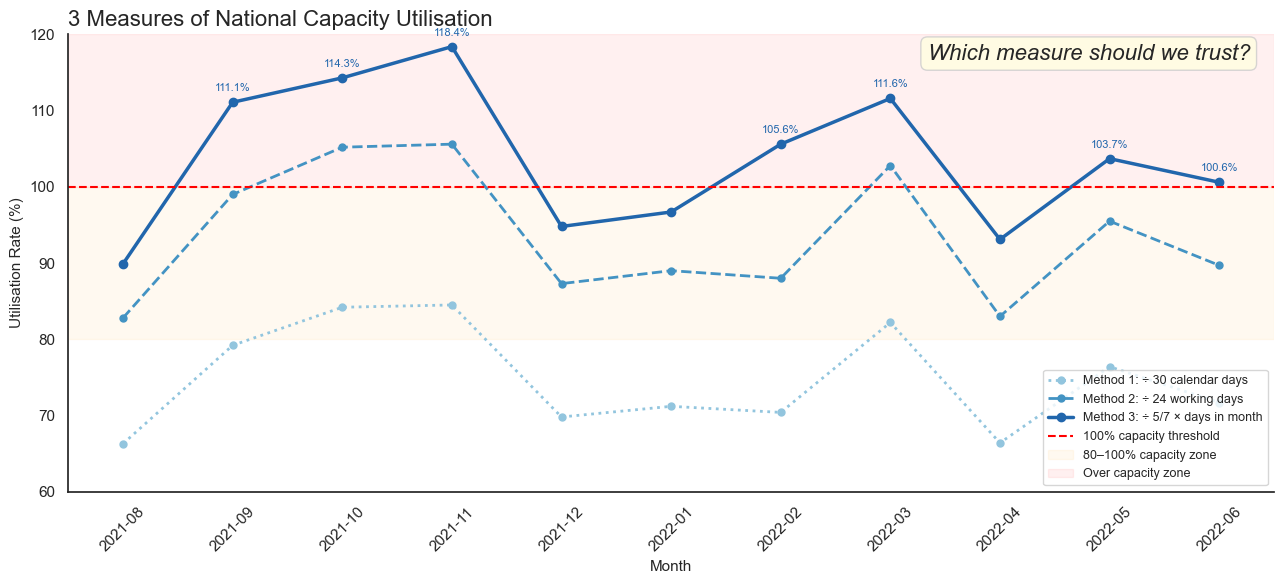

In [210]:
# CHART 2: Three Measures of National Capacity

# Analytical question: Has there been adequate capacity in the networks?
# Refined from the initial analysis in section 2.1


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import calendar

# Recalculate all three methods from ar_df (national aggregate)
ar_df_chart = ar_2021.groupby('appointment_month')['count_of_appointments'].sum().reset_index()
ar_df_chart['appointment_month'] = ar_df_chart['appointment_month'].astype(str)
ar_df_chart['days_in_month'] = ar_df_chart['appointment_month'].apply(
    lambda x: calendar.monthrange(int(x[:4]), int(x[5:7]))[1]
)

# Method 1: 30 calendar days 
ar_df_chart['util_30'] = (ar_df_chart['count_of_appointments'] / 30 / 1200000 * 100).round(1)
# Method 2: 24 working days 
ar_df_chart['util_24'] = (ar_df_chart['count_of_appointments'] / 24 / 1200000 * 100).round(1)
# Method 3: 5/7 x days in month 
ar_df_chart['working_days_5'] = (ar_df_chart['days_in_month'] * 5 / 7).round(1)
ar_df_chart['util_5'] = (ar_df_chart['count_of_appointments'] /
                          ar_df_chart['working_days_5'] / 1200000 * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(ar_df_chart['appointment_month'], ar_df_chart['util_30'],
        color='#92c5de', linestyle=':', linewidth=2, marker='o', markersize=5,
        label='Method 1: ÷ 30 calendar days')
ax.plot(ar_df_chart['appointment_month'], ar_df_chart['util_24'],
        color='#4393c3', linestyle='--', linewidth=2, marker='o', markersize=5,
        label='Method 2: ÷ 24 working days')
ax.plot(ar_df_chart['appointment_month'], ar_df_chart['util_5'],
        color='#2166ac', linestyle='-', linewidth=2.5, marker='o', markersize=6,
        label='Method 3: ÷ 5/7 × days in month')

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5,
           label='100% capacity threshold')
ax.axhspan(80, 100, alpha=0.06, color='orange', label='80–100% capacity zone')
ax.axhspan(100, 120, alpha=0.06, color='red', label='Over capacity zone')

# Annotate peaks on Method 3
for _, row in ar_df_chart[ar_df_chart['util_5'] > 100].iterrows():
    ax.annotate(f"{row['util_5']:.1f}%",
                (row['appointment_month'], row['util_5']),
                textcoords='offset points', xytext=(0, 8),
                fontsize=8, color='#2166ac', ha='center')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Utilisation Rate (%)', fontsize=11)
ax.set_title(
    '3 Measures of National Capacity Utilisation',
    fontsize=16, loc='left'
)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(60, 120)
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Key takeaway annotation — upper right
ax.annotate(
    'Which measure should we trust?',
  
    xy=(0.98, 0.98),
    xycoords='axes fraction',
    fontsize=16,
    style='italic',
    va='top',
    ha='right',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='lightyellow',
              edgecolor='#cccccc',
              alpha=0.8)
)

plt.tight_layout()
plt.savefig('summary_chart_1_utilisation_methods.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings

1. The assumptions made about the number of working days significantly affect the results.
2. Method 3 validated by the day-of-week analysis in section 2.2 
3. Saturday appointments confirmed as predominantly planned procedures (see section 2.2) 

Note:  
All three methods use the NHS theoretical maximum of 1,200,000 appointments per day nationally.  
This is a published benchmark figure, not derived from the data itself. 

**Conclusion:**  
There has not been adequate capacity in the network: this is a picture of a system under pressure.


**Key Finding:**
Empirical evidence confirms the validity of using a 5 day working week.   
See the day-of-week breakdown in section 2.2.  
Method 3 in Chart 2 is the most accurate measure of utilisation rates over the period.  
The NHS is operating under severe capacity pressure.

---
# 3. ICB-level analysis: a divergent pattern in North West London

The national benchmark was apportioned across the five largest ICBs by
appointment volume. One ICB does not behave like the others.

## 3.1 Analysis of the five largest ICBs

In [126]:
# Define the five largest ICBs 
top5_icbs = {
    'E54000008': 'Cheshire & Merseyside',
    'E54000027': 'North West London',
    'E54000050': 'NE & North Cumbria',
    'E54000054': 'West Yorkshire',
    'E54000057': 'Greater Manchester'
}

# Filter ar_2021 to these five ICBs
ar_top5 = ar_2021[ar_2021['icb_ons_code'].isin(top5_icbs.keys())]

# Group by ICB and month
ar_top5_df = ar_top5.groupby(
    ['icb_ons_code', 'appointment_month']
)['count_of_appointments'].sum().reset_index()

# Add days in month and working days
import calendar
ar_top5_df['days_in_month'] = ar_top5_df['appointment_month'].apply(
    lambda x: calendar.monthrange(int(x[:4]), int(x[5:7]))[1]
)
ar_top5_df['working_days_55'] = (
    ar_top5_df['days_in_month'] * 5.5 / 7
).round(1)

# Calculate utilisation rate
ar_top5_df['utilisation_rate_55'] = (
    ar_top5_df['count_of_appointments'] /
    ar_top5_df['working_days_55'] /
    1200000 * 100
).round(1)

# Map ICB codes to readable names
ar_top5_df['icb_name'] = ar_top5_df['icb_ons_code'].map(top5_icbs)
ar_top5_df['appointment_month'] = ar_top5_df['appointment_month'].astype(str)

print(ar_top5_df[['icb_name', 'appointment_month', 
                   'count_of_appointments', 'utilisation_rate_55']])

                 icb_name appointment_month  count_of_appointments  \
0   Cheshire & Merseyside           2021-08                1064804   
1   Cheshire & Merseyside           2021-09                1310834   
2   Cheshire & Merseyside           2021-10                1379405   
3   Cheshire & Merseyside           2021-11                1366727   
4   Cheshire & Merseyside           2021-12                1112173   
..                    ...               ...                    ...   
50     Greater Manchester           2022-02                1191581   
51     Greater Manchester           2022-03                1412576   
52     Greater Manchester           2022-04                1118651   
53     Greater Manchester           2022-05                1292042   
54     Greater Manchester           2022-06                1215649   

    utilisation_rate_55  
0                   3.6  
1                   4.6  
2                   4.7  
3                   4.8  
4                   3.8  
.. 

**Observation:** The utilisation rates are being calculated against a national capacity figure and need to be adjusted 
based on their appointment counts as a percentage to total.

In [132]:
# Calculate each ICB's share of national appointments
national_total = ar_2021['count_of_appointments'].sum()

icb_totals = ar_2021.groupby(
    'icb_ons_code')['count_of_appointments'].sum()

icb_share = icb_totals / national_total

# Add proportioned daily capacity to ar_top5_df
ar_top5_df['icb_capacity'] = ar_top5_df['icb_ons_code'].map(
    icb_share * 1200000
)

# Recalculate utilisation rate
ar_top5_df['utilisation_rate_55'] = (
    ar_top5_df['count_of_appointments'] /
    ar_top5_df['working_days_55'] /
    ar_top5_df['icb_capacity'] * 100
).round(1)

# Verify
print(ar_top5_df[['icb_name', 'appointment_month',
                   'icb_capacity',
                   'utilisation_rate_55']].head(15))

                 icb_name appointment_month  icb_capacity  utilisation_rate_55
0   Cheshire & Merseyside           2021-08  53708.990644                 81.3
1   Cheshire & Merseyside           2021-09  53708.990644                103.4
2   Cheshire & Merseyside           2021-10  53708.990644                105.3
3   Cheshire & Merseyside           2021-11  53708.990644                107.8
4   Cheshire & Merseyside           2021-12  53708.990644                 84.9
5   Cheshire & Merseyside           2022-01  53708.990644                 87.5
6   Cheshire & Merseyside           2022-02  53708.990644                 95.7
7   Cheshire & Merseyside           2022-03  53708.990644                101.6
8   Cheshire & Merseyside           2022-04  53708.990644                 83.8
9   Cheshire & Merseyside           2022-05  53708.990644                 92.8
10  Cheshire & Merseyside           2022-06  53708.990644                 89.0
11      North West London           2021-08  49218.1

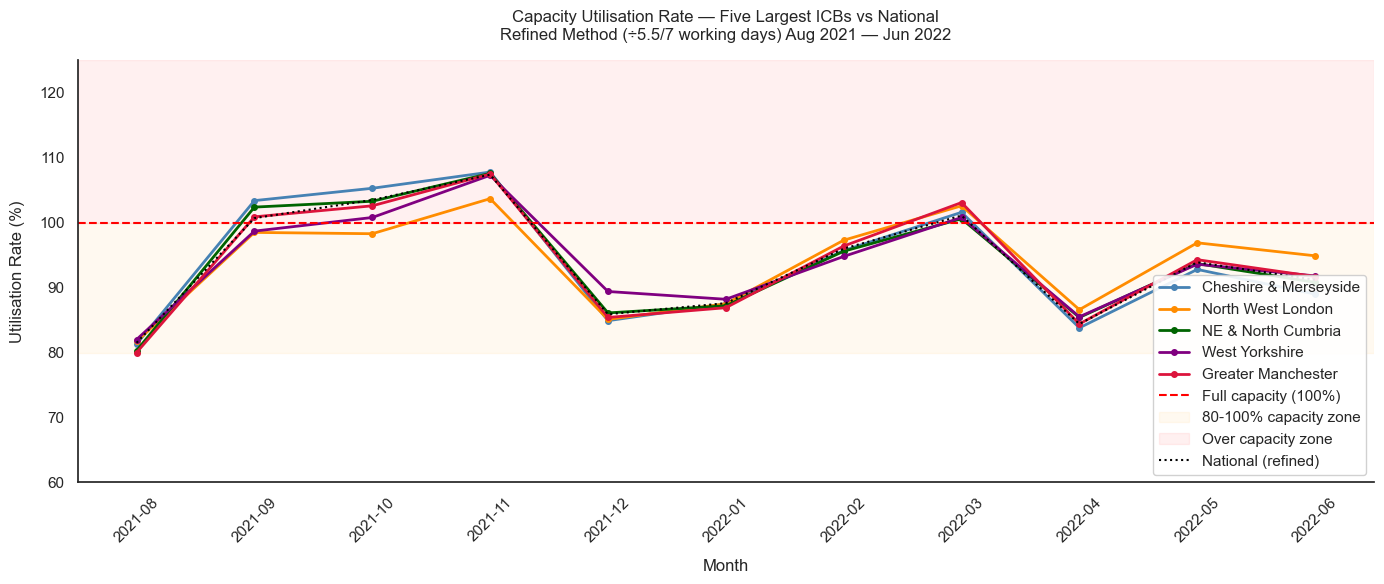

In [133]:
# Chart 4: a distinct pattern emerges in NWL

# Plot the chart
fig, ax = plt.subplots(figsize=(14, 6))

colours = ['steelblue', 'darkorange',
           'darkgreen', 'purple', 'crimson']

for (icb_code, name), colour in zip(top5_icbs.items(), colours):
    subset = ar_top5_df[ar_top5_df['icb_ons_code'] == icb_code]
    ax.plot(subset['appointment_month'],
            subset['utilisation_rate_55'],
            color=colour, linewidth=2, label=name,
            marker='o', markersize=4)

# Reference lines and shading
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.06, color='orange',
           label='80-100% capacity zone')
ax.axhspan(100, 125, alpha=0.06, color='red',
           label='Over capacity zone')

# National refined rate for comparison
ax.plot(ar_df['appointment_month'],
        ar_df['utilisation_rate_55'],
        color='black', linewidth=1.5,
        linestyle=':', label='National (refined)',
        zorder=5)

ax.set_title('Capacity Utilisation Rate — Five Largest ICBs vs National\n'
             'Refined Method (÷5.5/7 working days) Aug 2021 — Jun 2022',
             pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
ax.set_ylim(60, 125)
plt.xticks(rotation=45)
plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
sns.despine()
plt.show()

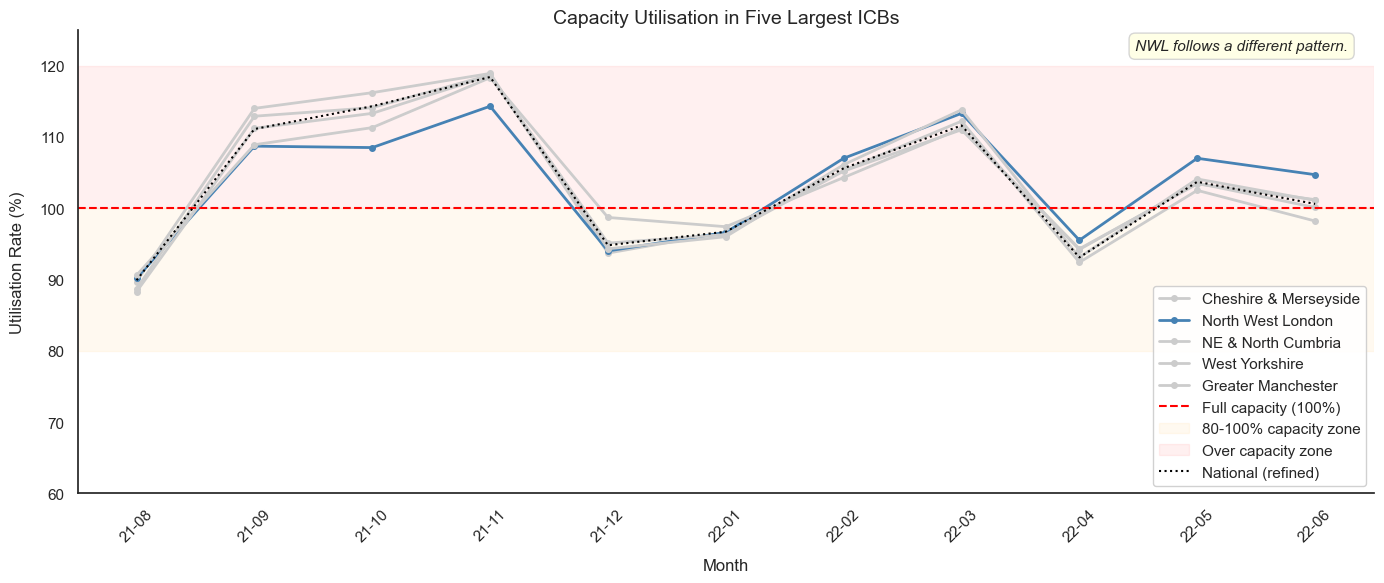

In [212]:
# CHART 4: Capacity Utilisation for 5 Largest ICBs
# Capacity apportioned to each ICB based on 1.2 million national daily
# Refined from the initial analysis earlier in this section
# Now with 5 working days a week assumption instead of 5.5

# Build the Top 5 ICB dataframe
top5_icbs = {
    'E54000008': 'Cheshire & Merseyside',
    'E54000027': 'North West London',
    'E54000050': 'NE & North Cumbria',
    'E54000054': 'West Yorkshire',
    'E54000057': 'Greater Manchester'
}

ar_top5 = ar_2021[ar_2021['icb_ons_code'].isin(top5_icbs.keys())]

ar_top5_df = ar_top5.groupby(
    ['icb_ons_code', 'appointment_month']
)['count_of_appointments'].sum().reset_index()

import calendar
ar_top5_df['days_in_month'] = ar_top5_df['appointment_month'].apply(
    lambda x: calendar.monthrange(int(x[:4]), int(x[5:7]))[1]
)

# Calculate 5-day working days
ar_top5_df['working_days_5'] = (ar_top5_df['days_in_month'] * 5 / 7).round(1)

# Map ICB names and format month to yy-mm
ar_top5_df['icb_name'] = ar_top5_df['icb_ons_code'].map(top5_icbs)
ar_top5_df['appointment_month'] = pd.to_datetime(
    ar_top5_df['appointment_month']
).dt.strftime('%y-%m')

# Calculate each ICB's share of national appointments
national_total = ar_2021['count_of_appointments'].sum()
icb_totals = ar_2021.groupby('icb_ons_code')['count_of_appointments'].sum()
icb_share = icb_totals / national_total

# Map each ICB's proportional capacity benchmark
ar_top5_df['icb_capacity'] = ar_top5_df['icb_ons_code'].map(icb_share * 1200000)

# Calculate utilisation rate against ICB-proportioned capacity
ar_top5_df['util_5'] = (
    ar_top5_df['count_of_appointments'] /
    ar_top5_df['working_days_5'] /
    ar_top5_df['icb_capacity'] * 100
).round(1)

# Create formatted copy of national data for this chart only
ar_df_chart_fmt = ar_df_chart.copy()
ar_df_chart_fmt['appointment_month'] = pd.to_datetime(
    ar_df_chart_fmt['appointment_month']
).dt.strftime('%y-%m')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

colours = ['#cccccc', 'steelblue',
           '#cccccc', '#cccccc', '#cccccc']

for (icb, name), colour in zip(top5_icbs.items(), colours):
    subset = ar_top5_df[ar_top5_df['icb_name'] == name]
    ax.plot(subset['appointment_month'],
            subset['util_5'],
            color=colour, linewidth=2, label=name, marker='o',
            markersize=4)

# Reference lines and shading
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.06, color='orange',
           label='80-100% capacity zone')
ax.axhspan(100, 120, alpha=0.06, color='red',
           label='Over capacity zone')

# National rate for comparison
ax.plot(ar_df_chart_fmt['appointment_month'],
        ar_df_chart_fmt['util_5'],
        color='black', linewidth=1.5,
        linestyle=':', label='National (refined)',
        zorder=5)

ax.set_title('Capacity Utilisation in Five Largest ICBs',
             pad=5, fontsize=14)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
ax.set_ylim(60, 125)
plt.xticks(rotation=45)
plt.legend(loc='lower right', framealpha=0.9)

# Key takeaway annotation
ax.annotate(
    'NWL follows a different pattern.',
    xy=(0.98, 0.98),
    xycoords='axes fraction',
    fontsize=11,
    style='italic',
    va='top',
    ha='right',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow',
              edgecolor='#cccccc',
              alpha=0.8)
)

plt.tight_layout()
sns.despine()
plt.show()

# Key Findings:  

1. Switching from a 5.5 working day model to a 5 day model raises the reported utilisation rates in this chart compared to the original (shown earlier in this section)
2. Something different is happening in North West London which merits further scrutiny. Their capacity utilisation rate differs in both directions from the national rate and also that of the other 4 largest ICBs. At the start of the period, North West London ICB (NWL) was operating at a lower level of capacity utilisation than the national average. The lines merge in December and January and in every subsequent month, NWL is closer to maximum capacity than both the national average and also the other 4 largest ICBs.
3. Cheshire and Merseyside chosen for comparative analysis. They have similar registered populations and a similar range of appointments per month and so are directly comparable in terms of both size and overall patient demand.

**Summary of exploratory comparisons carried out above to investigate factors which might be driving this divergence.**

**Observation:** North West London seems to diverge more than the others from the national average line. Plot this alone to investigate.

## 3.2 NWL investigation

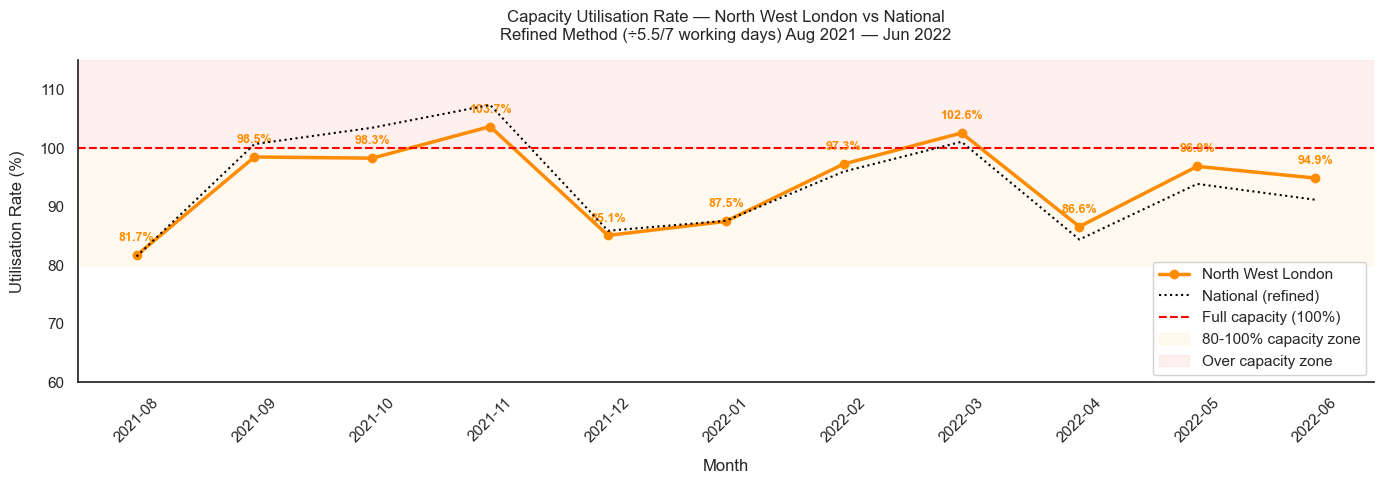

In [134]:
# Filter to North West London only
nwl = ar_top5_df[ar_top5_df['icb_ons_code'] == 'E54000027'].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# North West London line
ax.plot(nwl['appointment_month'],
        nwl['utilisation_rate_55'],
        color='darkorange', linewidth=2.5,
        marker='o', markersize=6,
        label='North West London')

# National refined for comparison
ax.plot(ar_df['appointment_month'],
        ar_df['utilisation_rate_55'],
        color='black', linewidth=1.5,
        linestyle=':', label='National (refined)',
        zorder=5)

# Annotate each NWL data point
for idx, row in nwl.iterrows():
    ax.annotate(f"{row['utilisation_rate_55']}%",
                xy=(row['appointment_month'],
                    row['utilisation_rate_55']),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=9,
                color='darkorange', fontweight='bold')

# Reference lines
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Full capacity (100%)')
ax.axhspan(80, 100, alpha=0.06, color='orange',
           label='80-100% capacity zone')
ax.axhspan(100, 115, alpha=0.06, color='red',
           label='Over capacity zone')

ax.set_title('Capacity Utilisation Rate — North West London vs National\n'
             'Refined Method (÷5.5/7 working days) Aug 2021 — Jun 2022',
             pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('Utilisation Rate (%)', labelpad=10)
ax.set_ylim(60, 115)
plt.xticks(rotation=45)
plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
sns.despine()
plt.show()

### Key Finding
At the start of the period, North West London ICB (NWL) was operating at a lower level of capacity utilisation than the national average. The lines merge in December and January and in every subsequent month, NWL is closer to maximum capacity than both the national average and also the other 4 largest ICBs.

**Next steps:**
Investigate other factors which might be driving this divergence.

## 3.3 Six hypotheses for the NWL divergence

Each of the following was tested as a possible explanation and set aside
before the category mix analysis identified the driver.

In [135]:
# NWL investigation 1: check the DNA rate per ICB across  period

# DNA rate calculated as total DNA appointments / total appointments x 100
# across the full 2021 period. This weights busier months more heavily
# than averaging monthly rates would, but gives a truer overall picture.
icb_totals = ar_2021.groupby('icb_ons_code')['count_of_appointments'].sum()

icb_dna = ar_2021[ar_2021['appointment_status'] == 'DNA'].groupby(
    'icb_ons_code')['count_of_appointments'].sum()

icb_dna_rate = (icb_dna / icb_totals * 100).round(1)

# Build summary dataframe
icb_dna_summary = icb_dna_rate.reset_index()
icb_dna_summary.columns = ['icb_ons_code', 'mean']
icb_dna_summary['min'] = ar_2021[ar_2021['appointment_status'] == 'DNA'].groupby(
    'icb_ons_code')['count_of_appointments'].min().values
icb_dna_summary['max'] = ar_2021[ar_2021['appointment_status'] == 'DNA'].groupby(
    'icb_ons_code')['count_of_appointments'].max().values

# Sort by mean DNA rate descending
icb_dna_summary_sorted = icb_dna_summary.sort_values(
    'mean', ascending=False
).reset_index(drop=True)

# Find NWL in the DNA summary
print(icb_dna_summary_sorted[
    icb_dna_summary_sorted['icb_ons_code'] == 'E54000027'
])

# Also print its rank
nwl_rank = icb_dna_summary_sorted[
    icb_dna_summary_sorted['icb_ons_code'] == 'E54000027'
].index[0]

print(f"\nNWL DNA rank: {nwl_rank + 1} out of {len(icb_dna_summary_sorted)} ICBs")
print(f"(1 = highest DNA rate, {len(icb_dna_summary_sorted)} = lowest)")



   icb_ons_code  mean  min    max
13    E54000027   4.8    1  12823

NWL DNA rank: 14 out of 42 ICBs
(1 = highest DNA rate, 42 = lowest)


### Key Findings

NWL's DNA rate of 4.8% places it 14th out of 42 ICBs, above the national average but not in the top quartile. This confirms that the DNA rate is not the 
driver of NWL's divergent utilisation pattern.

**Note:** The 4.8% rate is calculated as total DNA appointments divided by total appointments across the 11-month period August 2021 to June 2022, which weights busier months more heavily than a simple monthly average would. 

**Next step:**
Having lived in NWL throughout this period, I distinctly remember the relative scarcity of access to medical services (compared to friends and family in other locations). Check if there are more patients registered with each practice in NWL than in other ICBs.


In [136]:
# NWL Investigation 2: check the size of patient lists in NWL.  
# Calculate appointments per head by combining the appointment data with population estimates:
# Total appointments per ICB across the full period
icb_total_appts = ar_2021.groupby(
    'icb_ons_code')['count_of_appointments'].sum().reset_index()

# Population estimates for the five ICBs (2021 census approximations)
icb_population = {
    'E54000008': 2900000,  # Cheshire & Merseyside
    'E54000027': 2100000,  # North West London
    'E54000050': 3200000,  # NE & North Cumbria
    'E54000054': 2400000,  # West Yorkshire
    'E54000057': 2800000,  # Greater Manchester
}

# Filter to top 5 and add population
top5_appts = icb_total_appts[
    icb_total_appts['icb_ons_code'].isin(top5_icbs.keys())
].copy()

top5_appts['icb_name'] = top5_appts['icb_ons_code'].map(top5_icbs)
top5_appts['population'] = top5_appts['icb_ons_code'].map(icb_population)

# Appointments per head across the 11-month period
top5_appts['appts_per_head'] = (
    top5_appts['count_of_appointments'] /
    top5_appts['population']
).round(2)

# Monthly equivalent
top5_appts['appts_per_head_per_month'] = (
    top5_appts['appts_per_head'] / 11
).round(3)

print(top5_appts[[
    'icb_name', 'count_of_appointments',
    'population', 'appts_per_head',
    'appts_per_head_per_month'
]].sort_values('appts_per_head', ascending=False))



                 icb_name  count_of_appointments  population  appts_per_head  \
33         West Yorkshire               14358371     2400000            5.98   
12      North West London               12142390     2100000            5.78   
29     NE & North Cumbria               16882235     3200000            5.28   
36     Greater Manchester               13857900     2800000            4.95   
0   Cheshire & Merseyside               13250311     2900000            4.57   

    appts_per_head_per_month  
33                     0.544  
12                     0.525  
29                     0.480  
36                     0.450  
0                      0.415  


**Observation:**
The number of appointments per head per month is high, but it isn't the highest in our list of 5. West Yorkshire ICB had a higher rate and was better able to operate within capacity during the start of this period.

**Conclusion:**
The list size (as measured by the number of appointments per head) may be a contributing factor but it is not the sole driver of the divergence. There may also be a capacity contraint putting further pressure on medical services in NWL.

**Next step:**
Check the appointment mode mix to see if there are noticeable differences in how patients in NWL were seen (both in comparison to other ICBs and within NWL over the full time period when the capacity issues seemed to improve rapidly at a time when other ICBs were struggling.)

In [137]:
# NWL investigation 3: Look at NWL's appointment MODE mix over time to look for changes in, eg the proportion of face-to-face vs telephone appointments.
nwl_mode = ar_2021[
    ar_2021['icb_ons_code'] == 'E54000027'
].groupby(
    ['appointment_month', 'appointment_mode']
)['count_of_appointments'].sum().reset_index()

# Calculate mode proportions
nwl_mode_total = nwl_mode.groupby(
    'appointment_month')['count_of_appointments'].transform('sum')
nwl_mode['proportion'] = (
    nwl_mode['count_of_appointments'] / nwl_mode_total * 100
).round(1)

nwl_mode['appointment_month'] = nwl_mode['appointment_month'].astype(str)

print(nwl_mode.pivot_table(
    index='appointment_month',
    columns='appointment_mode',
    values='proportion'
).round(1))

appointment_mode   Face-to-Face  Home Visit  Telephone  Unknown  Video/Online
appointment_month                                                            
2021-08                    55.7         0.2       39.6      1.8           2.7
2021-09                    57.7         0.2       37.2      2.2           2.6
2021-10                    60.5         0.3       34.1      2.6           2.5
2021-11                    60.0         0.3       34.8      2.3           2.6
2021-12                    58.3         0.3       36.8      2.1           2.6
2022-01                    57.1         0.2       38.2      1.6           2.9
2022-02                    58.6         0.2       36.8      1.7           2.7
2022-03                    59.5         0.3       35.8      1.8           2.7
2022-04                    59.5         0.3       35.7      1.7           2.8
2022-05                    60.5         0.3       34.7      1.7           2.7
2022-06                    61.3         0.2       34.0      1.8 

**Observation:**
The proportion of unknown modes falls considerably around the time when NWL became better able to cope with patient demand, 
falling from 2.6% in October to 1.6% in January, exactly when the utilisation lines cross. There is no way of knowing if there is any causal relationship between these stats.

In [138]:
# NWL investigation 3: Look at NWL's appointment MODE mix over time compared to the other large ICBs:
# Did NWL have a different proportion of face-to-face vs telephone appointments?

# Mode mix for all five large ICBs
top5_mode = ar_2021[
    ar_2021['icb_ons_code'].isin(top5_icbs.keys())
].groupby(
    ['icb_ons_code', 'appointment_mode']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions within each ICB
top5_mode_total = top5_mode.groupby(
    'icb_ons_code')['count_of_appointments'].transform('sum')
top5_mode['proportion'] = (
    top5_mode['count_of_appointments'] / 
    top5_mode_total * 100
).round(1)

# Map ICB names
top5_mode['icb_name'] = top5_mode['icb_ons_code'].map(top5_icbs)

# Pivot for easy comparison
mode_comparison = top5_mode.pivot_table(
    index='icb_name',
    columns='appointment_mode',
    values='proportion'
).round(1)

print(mode_comparison)

appointment_mode       Face-to-Face  Home Visit  Telephone  Unknown  \
icb_name                                                              
Cheshire & Merseyside          59.2         1.4       37.5      1.6   
Greater Manchester             58.2         1.4       34.8      5.4   
NE & North Cumbria             67.1         0.7       29.0      2.9   
North West London              59.0         0.2       36.1      2.0   
West Yorkshire                 66.9         0.4       28.9      3.2   

appointment_mode       Video/Online  
icb_name                             
Cheshire & Merseyside           0.3  
Greater Manchester              0.2  
NE & North Cumbria              0.3  
North West London               2.7  
West Yorkshire                  0.6  


**Observation:** On average throughout this period, NWL reported more use of video/online appointments than other large ICBs.  
**Next step:** Chart the month by month figures for video appointments in NWL to see if this became more common later in the period when the ICB reported working more comfortable within capacity.
    

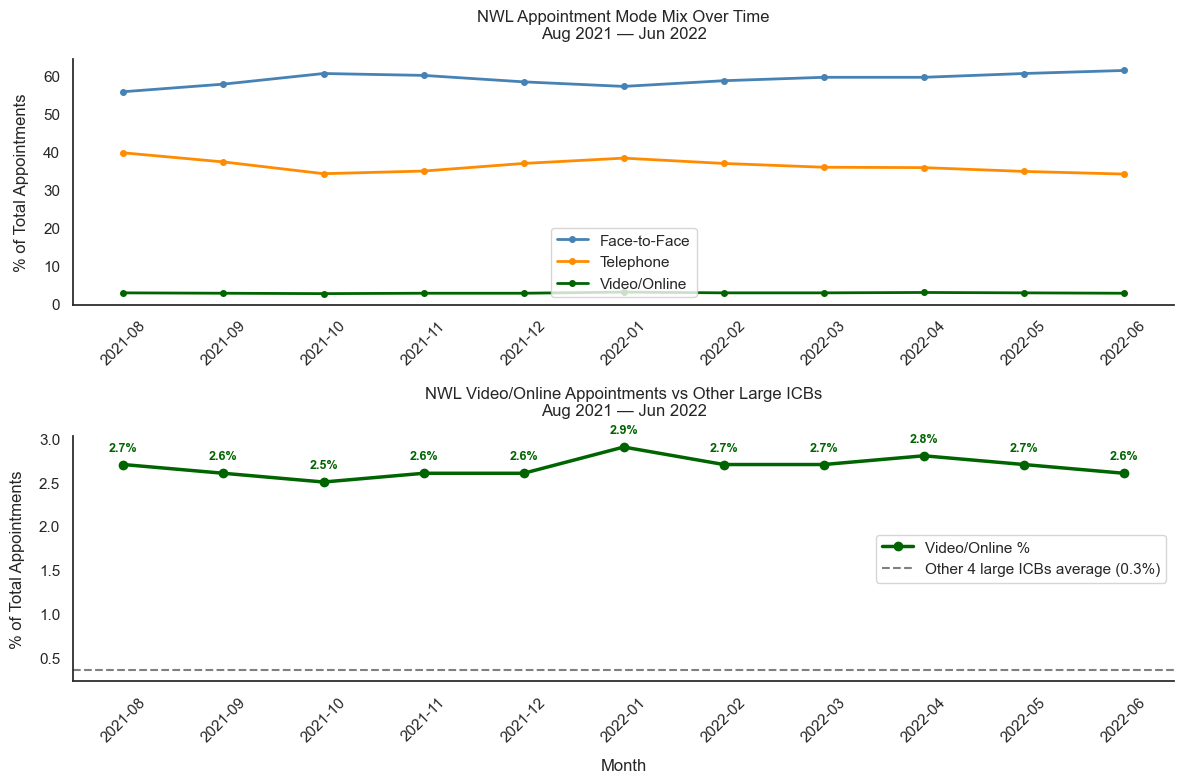

In [139]:
# NWL Investigation 4: Plot the use of Video/Online appointments within NWL over time
nwl_video = nwl_mode[
    nwl_mode['appointment_mode'] == 'Video/Online'
].copy()

# Also get Face-to-Face and Telephone for context
nwl_key_modes = nwl_mode[
    nwl_mode['appointment_mode'].isin([
        'Face-to-Face', 'Telephone', 'Video/Online'
    ])
].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top panel: proportions of key modes over time
for mode, colour in [
    ('Face-to-Face', 'steelblue'),
    ('Telephone', 'darkorange'),
    ('Video/Online', 'darkgreen')
]:
    subset = nwl_key_modes[
        nwl_key_modes['appointment_mode'] == mode
    ]
    ax1.plot(subset['appointment_month'],
             subset['proportion'],
             color=colour, linewidth=2,
             marker='o', markersize=4,
             label=mode)

ax1.set_title('NWL Appointment Mode Mix Over Time\n'
              'Aug 2021 — Jun 2022', pad=15)
ax1.set_xlabel('')
ax1.set_ylabel('% of Total Appointments', labelpad=10)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
sns.despine(ax=ax1)

# Bottom panel: Video/Online proportion with annotations
ax2.plot(nwl_video['appointment_month'],
         nwl_video['proportion'],
         color='darkgreen', linewidth=2.5,
         marker='o', markersize=6,
         label='Video/Online %')

# Add comparison line for national average of other ICBs
other_avg = (0.3 + 0.2 + 0.3 + 0.6) / 4
ax2.axhline(y=other_avg, color='grey',
            linestyle='--', linewidth=1.5,
            label=f'Other 4 large ICBs average ({other_avg:.1f}%)')

# Annotate each point
for idx, row in nwl_video.iterrows():
    ax2.annotate(f"{row['proportion']}%",
                 xy=(row['appointment_month'],
                     row['proportion']),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', fontsize=9,
                 color='darkgreen',
                 fontweight='bold')

ax2.set_title('NWL Video/Online Appointments vs Other Large ICBs\n'
              'Aug 2021 — Jun 2022', pad=15)
ax2.set_xlabel('Month', labelpad=10)
ax2.set_ylabel('% of Total Appointments', labelpad=10)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

**Observations:**
Video appointments in NWL were used roughly 9 times more than in the other large ICBs throughout the entire period. This is interesting but, NWL's use of video appointments was fairly consistent over the period so it is not the reason why this ICB started performing better against the capacity metric.

**Next step:**
Explore the HCP type mix to identify whether NWL's GP vs Other Practice Staff ratio changed around December 2021.

In [140]:
# NWL Investigation 5: plot the HCP type mix in NWL over the period.
# NWL HCP type mix over time
nwl_hcp = ar_2021[
    ar_2021['icb_ons_code'] == 'E54000027'
].groupby(
    ['appointment_month', 'hcp_type']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions
nwl_hcp_total = nwl_hcp.groupby(
    'appointment_month')['count_of_appointments'].transform('sum')
nwl_hcp['proportion'] = (
    nwl_hcp['count_of_appointments'] / 
    nwl_hcp_total * 100
).round(1)

nwl_hcp['appointment_month'] = nwl_hcp['appointment_month'].astype(str)

# Pivot for easy reading
nwl_hcp_pivot = nwl_hcp.pivot_table(
    index='appointment_month',
    columns='hcp_type',
    values='proportion'
).round(1)

print(nwl_hcp_pivot)

hcp_type             GP  Other Practice staff  Unknown
appointment_month                                     
2021-08            54.1                  43.6      2.3
2021-09            53.6                  43.6      2.8
2021-10            51.4                  45.4      3.2
2021-11            53.0                  44.2      2.8
2021-12            53.8                  43.6      2.5
2022-01            54.1                  43.7      2.2
2022-02            53.3                  44.5      2.2
2022-03            53.6                  44.1      2.3
2022-04            52.0                  45.7      2.3
2022-05            52.2                  45.4      2.3
2022-06            51.8                  45.6      2.5


**Observation:** 

There is a definite movement over the period towards a greater use of other practice staff in NWL but the October figures in the table above don't match the utilisation story for that month, so again, this may be a contributing factor, but it is not the key to understanding why NWL's capacity diverges so much (at both ends of the period) from the other large ICBs. Something else is the driver.

**Next step:** 

Compare the pattern of NWL's HCP mix over time with the pattern in the other largest ICBs.

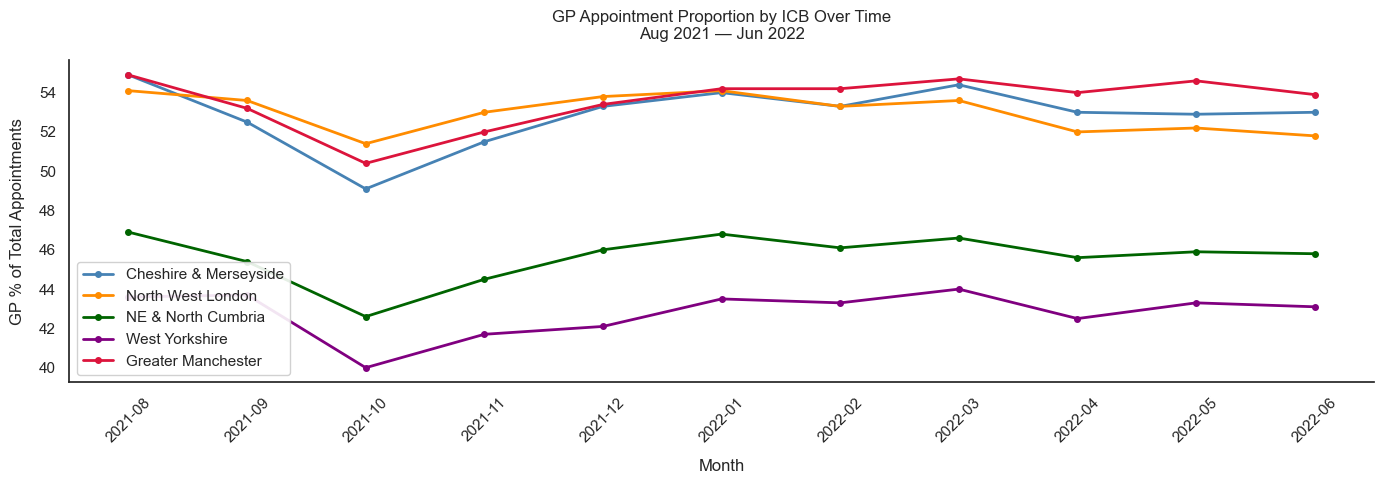

In [141]:
# NWL capacity investigation 6: Look at the monthly HCP mix for five largest ICBs

top5_hcp_monthly = ar_2021[
    ar_2021['icb_ons_code'].isin(top5_icbs.keys())
].groupby(
    ['icb_ons_code', 'appointment_month', 'hcp_type']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions
top5_hcp_monthly_total = top5_hcp_monthly.groupby(
    ['icb_ons_code', 'appointment_month']
)['count_of_appointments'].transform('sum')

top5_hcp_monthly['proportion'] = (
    top5_hcp_monthly['count_of_appointments'] /
    top5_hcp_monthly_total * 100
).round(1)

top5_hcp_monthly['icb_name'] = top5_hcp_monthly[
    'icb_ons_code'].map(top5_icbs)
top5_hcp_monthly['appointment_month'] = top5_hcp_monthly[
    'appointment_month'].astype(str)

# Plot GP proportion only — most informative signal
gp_monthly = top5_hcp_monthly[
    top5_hcp_monthly['hcp_type'] == 'GP'
]

fig, ax = plt.subplots(figsize=(14, 5))

colours = ['steelblue', 'darkorange',
           'darkgreen', 'purple', 'crimson']

for (icb_code, name), colour in zip(top5_icbs.items(), colours):
    subset = gp_monthly[gp_monthly['icb_name'] == name]
    ax.plot(subset['appointment_month'],
            subset['proportion'],
            color=colour, linewidth=2,
            marker='o', markersize=4,
            label=name)

ax.set_title('GP Appointment Proportion by ICB Over Time\n'
             'Aug 2021 — Jun 2022', pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('GP % of Total Appointments', labelpad=10)
plt.xticks(rotation=45)
plt.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
sns.despine()
plt.show()

**Observation:** 

In this chart, NWL's HCP mix sits close to that of two other large ICBs. Over this period, we see a similar pattern as was noted in the utilisation chart. Of the three ICBs, NWL is using the highest proportion of GPs when capacity was most stretched (October) and had transitioned to using the highest proportion of other practice staff (of the three) when their capacity struggles eased (April). This is another contributing factor but not large enough in scale to provide the answer to the unusual capacity story we see in NWL over this period.

**Conclusion:**

Having tested 6 hypotheses to understand the key driver for the unusual trajectory of NWL's utilisation and capacity, it seems that this dataset suggests a number of small contributing factors but this doesn't tell the full story.

**Next steps:**

Look at the nc dataset, drilling down to sub ICBs in NWL.

---
# 4. Category mix: two models of managing patient access

The divergence is not explained by demand, staffing, appointment mode or
missed appointments. It is explained by what kind of appointments each ICB
offers.

In [142]:
# nc was loaded at the top of the notebook
# Reminder of nc dataset structure:
print(nc.shape)
print(nc.columns.tolist())
nc.head()
print(nc.shape)
print(nc.columns.tolist())
nc.head()

(817394, 8)
['appointment_date', 'icb_ons_code', 'sub_icb_location_name', 'service_setting', 'context_type', 'national_category', 'count_of_appointments', 'appointment_month']
(817394, 8)
['appointment_date', 'icb_ons_code', 'sub_icb_location_name', 'service_setting', 'context_type', 'national_category', 'count_of_appointments', 'appointment_month']


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01


In [143]:
# Check NWL sub-ICBs
nwl_nc = nc[nc['icb_ons_code'] == 'E54000027']

print(f"NWL rows in nc: {nwl_nc.shape[0]}")
print(f"\nNWL sub-ICBs:")
print(nwl_nc['sub_icb_location_name'].unique())

print(f"\nDate range:")
print(f"Min: {nwl_nc['appointment_date'].min()}")
print(f"Max: {nwl_nc['appointment_date'].max()}")

print(f"\nNational categories in NWL:")
print(nwl_nc['national_category'].value_counts())

NWL rows in nc: 13007

NWL sub-ICBs:
['NHS North West London ICB - W2U3Z']

Date range:
Min: 2021-08-01 00:00:00
Max: 2022-06-30 00:00:00

National categories in NWL:
national_category
Inconsistent Mapping                                                   1222
Planned Clinics                                                        1203
Clinical Triage                                                        1166
General Consultation Routine                                           1161
General Consultation Acute                                             1160
Planned Clinical Procedure                                             1121
Service provided by organisation external to the practice               919
Unplanned Clinical Activity                                             861
Structured Medication Review                                            730
Home Visit                                                              600
Walk-in                                                

**Observations:**

1. There is no sub ICB breakdown for North West London so a more granular analysis of capacity and utilisation needs to be done by looking at other fields.
2. Inconsistent mapping accounts for almost 10% of rows (but these are aggregated)

**Next step:**

Display appointment counts for comparison across categories.

In [144]:
# Compare appointment counts by category, not just row counts
nwl_category_counts = nwl_nc.groupby(
    'national_category')['count_of_appointments'].sum().sort_values(
    ascending=False).reset_index()

nwl_category_counts['percentage'] = (
    nwl_category_counts['count_of_appointments'] /
    nwl_category_counts['count_of_appointments'].sum() * 100
).round(1)

print(nwl_category_counts.to_string())

                                                      national_category  count_of_appointments  percentage
0                                          General Consultation Routine                3228687        26.6
1                                                       Planned Clinics                2340773        19.3
2                                                       Clinical Triage                1850292        15.2
3                                            General Consultation Acute                1548639        12.8
4                                                  Inconsistent Mapping                1249574        10.3
5                                                              Unmapped                 904234         7.4
6                                            Planned Clinical Procedure                 643581         5.3
7                                           Unplanned Clinical Activity                 134933         1.1
8                                    

**Observations:** 

1. When broken down by appointment count, unmapped accounts for 7.4% of NWL's appointments and inconsistent mapping accounts for 10.3%.
2. Routine GP appointments comprise 26.6% of all mapped categories and there are only 3 others with substantial counts.

**Next steps:**

1. Filter the dataset to include only these 4 categories and compare with other large ICBs for comparison.


## 4.1 Category mix analysis

In [145]:
# Compare national category mix across all five large ICBs
top5_categories = nc[
    nc['icb_ons_code'].isin(top5_icbs.keys())
].groupby(
    ['icb_ons_code', 'national_category']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions within each ICB
top5_cat_total = top5_categories.groupby(
    'icb_ons_code')['count_of_appointments'].transform('sum')
top5_categories['percentage'] = (
    top5_categories['count_of_appointments'] /
    top5_cat_total * 100
).round(1)

# Map names
top5_categories['icb_name'] = top5_categories[
    'icb_ons_code'].map(top5_icbs)

# Pivot to compare the four key categories across ICBs
key_cats = [
    'General Consultation Routine',
    'Planned Clinics',
    'Clinical Triage',
    'General Consultation Acute'
]

comparison = top5_categories[
    top5_categories['national_category'].isin(key_cats)
].pivot_table(
    index='icb_name',
    columns='national_category',
    values='percentage'
).round(1)

print(comparison)

national_category      Clinical Triage  General Consultation Acute  \
icb_name                                                             
Cheshire & Merseyside             17.9                        18.0   
Greater Manchester                12.2                        18.1   
NE & North Cumbria                12.5                        16.5   
North West London                 15.2                        12.8   
West Yorkshire                    12.2                        17.7   

national_category      General Consultation Routine  Planned Clinics  
icb_name                                                              
Cheshire & Merseyside                          32.7              6.4  
Greater Manchester                             32.3              6.8  
NE & North Cumbria                             38.2             10.9  
North West London                              26.6             19.3  
West Yorkshire                                 31.9             11.6  


### Key Finding

North West London has a very different mix of categories to the other large ICBs. 
Create individual line plots to explore this visually.

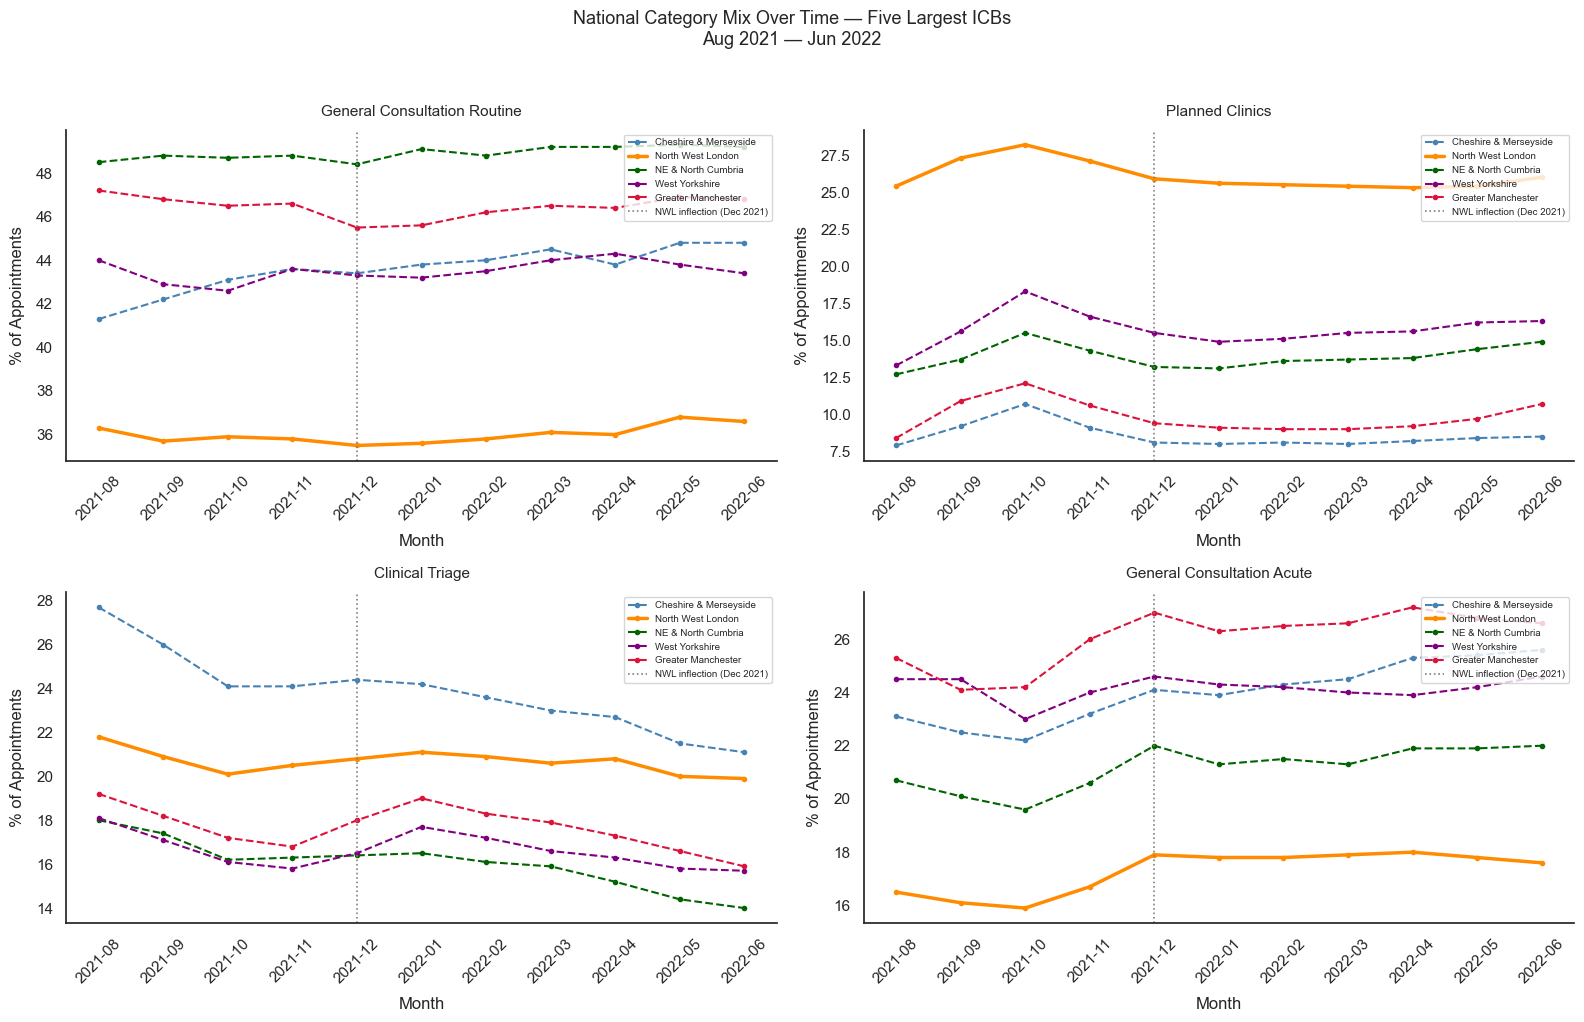

In [149]:
# Fix month ordering for top5_cat_monthly
top5_cat_monthly['appointment_month_dt'] = pd.to_datetime(
    top5_cat_monthly['appointment_month'])
top5_cat_monthly = top5_cat_monthly.sort_values(
    'appointment_month_dt')
top5_cat_monthly['appointment_month'] = top5_cat_monthly[
    'appointment_month_dt'].dt.strftime('%Y-%m')

# Replot all four categories with correct ordering
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, category in enumerate(key_cats):
    ax = axes[idx]
    cat_data = top5_cat_monthly[
        top5_cat_monthly['national_category'] == category
    ]

    for icb_name, colour in colours.items():
        subset = cat_data[
            cat_data['icb_name'] == icb_name
        ].sort_values('appointment_month_dt')
        lw = 2.5 if icb_name == 'North West London' else 1.5
        ls = '-' if icb_name == 'North West London' else '--'
        ax.plot(subset['appointment_month'],
                subset['percentage'],
                color=colour, linewidth=lw,
                linestyle=ls, marker='o',
                markersize=3, label=icb_name)

    # Add December inflection marker to all four charts
    ax.axvline(x='2021-12', color='grey',
               linestyle=':', linewidth=1.2,
               label='NWL inflection (Dec 2021)')

    ax.set_title(category, pad=10, fontsize=11)
    ax.set_xlabel('Month', labelpad=8)
    ax.set_ylabel('% of Appointments', labelpad=8)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, loc='upper right')
    sns.despine(ax=ax)

plt.suptitle('National Category Mix Over Time — Five Largest ICBs\n'
             'Aug 2021 — Jun 2022',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observation:**   
The vertical dotted line at December 2021 marks the point at which NWL's trajectory of demand and utilisation crossed from being the most pressured ICB to the least pressured.  We can also note this clinical triage model was operational in NWL throughout the period.

**Next step:**  
Add this December line to the other charts for clearer visibility of changes before and after this key point.

**Observation:** Given how low GP routine appointments in NWL are compared to the others, double check if unmapped and inconsistent mapping levels vary across the 5 ICBs.

In [150]:
# Data quality check — unmapped proportions across five ICBs
dq_cats = ['Inconsistent Mapping', 'Unmapped']

top5_dq = nc[
    nc['icb_ons_code'].isin(top5_icbs.keys())
].groupby(
    ['icb_ons_code', 'national_category']
)['count_of_appointments'].sum().reset_index()

# Total per ICB
icb_totals = top5_dq.groupby(
    'icb_ons_code')['count_of_appointments'].sum()

# Filter to data quality categories
top5_dq_only = top5_dq[
    top5_dq['national_category'].isin(dq_cats)
].copy()

top5_dq_only['icb_total'] = top5_dq_only[
    'icb_ons_code'].map(icb_totals)

top5_dq_only['percentage'] = (
    top5_dq_only['count_of_appointments'] /
    top5_dq_only['icb_total'] * 100
).round(1)

top5_dq_only['icb_name'] = top5_dq_only[
    'icb_ons_code'].map(top5_icbs)

# Pivot for comparison
dq_comparison = top5_dq_only.pivot_table(
    index='icb_name',
    columns='national_category',
    values='percentage'
).round(1)

# Add total unmapped
dq_comparison['Total unmapped %'] = (
    dq_comparison.sum(axis=1)
).round(1)

print(dq_comparison.sort_values(
    'Total unmapped %', ascending=False))

national_category      Inconsistent Mapping  Unmapped  Total unmapped %
icb_name                                                               
Greater Manchester                     12.8       7.2              20.0
North West London                      10.3       7.4              17.7
West Yorkshire                          9.9       4.9              14.8
Cheshire & Merseyside                  11.1       1.3              12.4
NE & North Cumbria                      8.4       2.8              11.2


**Observation:**   
NWL has the highest unmapped appointment proportion among the five ICBs at 7.4%, compared to 1.3% for Cheshire & Merseyside. This difference in data quality between the two must be acknowledged when comparing appointment categories. However, the gap in Planned Clinics proportion between NWL (19.3%) and Cheshire & Merseyside (6.4%) is approximately 13 percentage points, which is more than double the unmapped proportion difference. Even if NWL's unmapped appointments were all routine GP consultations, the structural difference in Planned Clinics delivery would still be analytically significant.

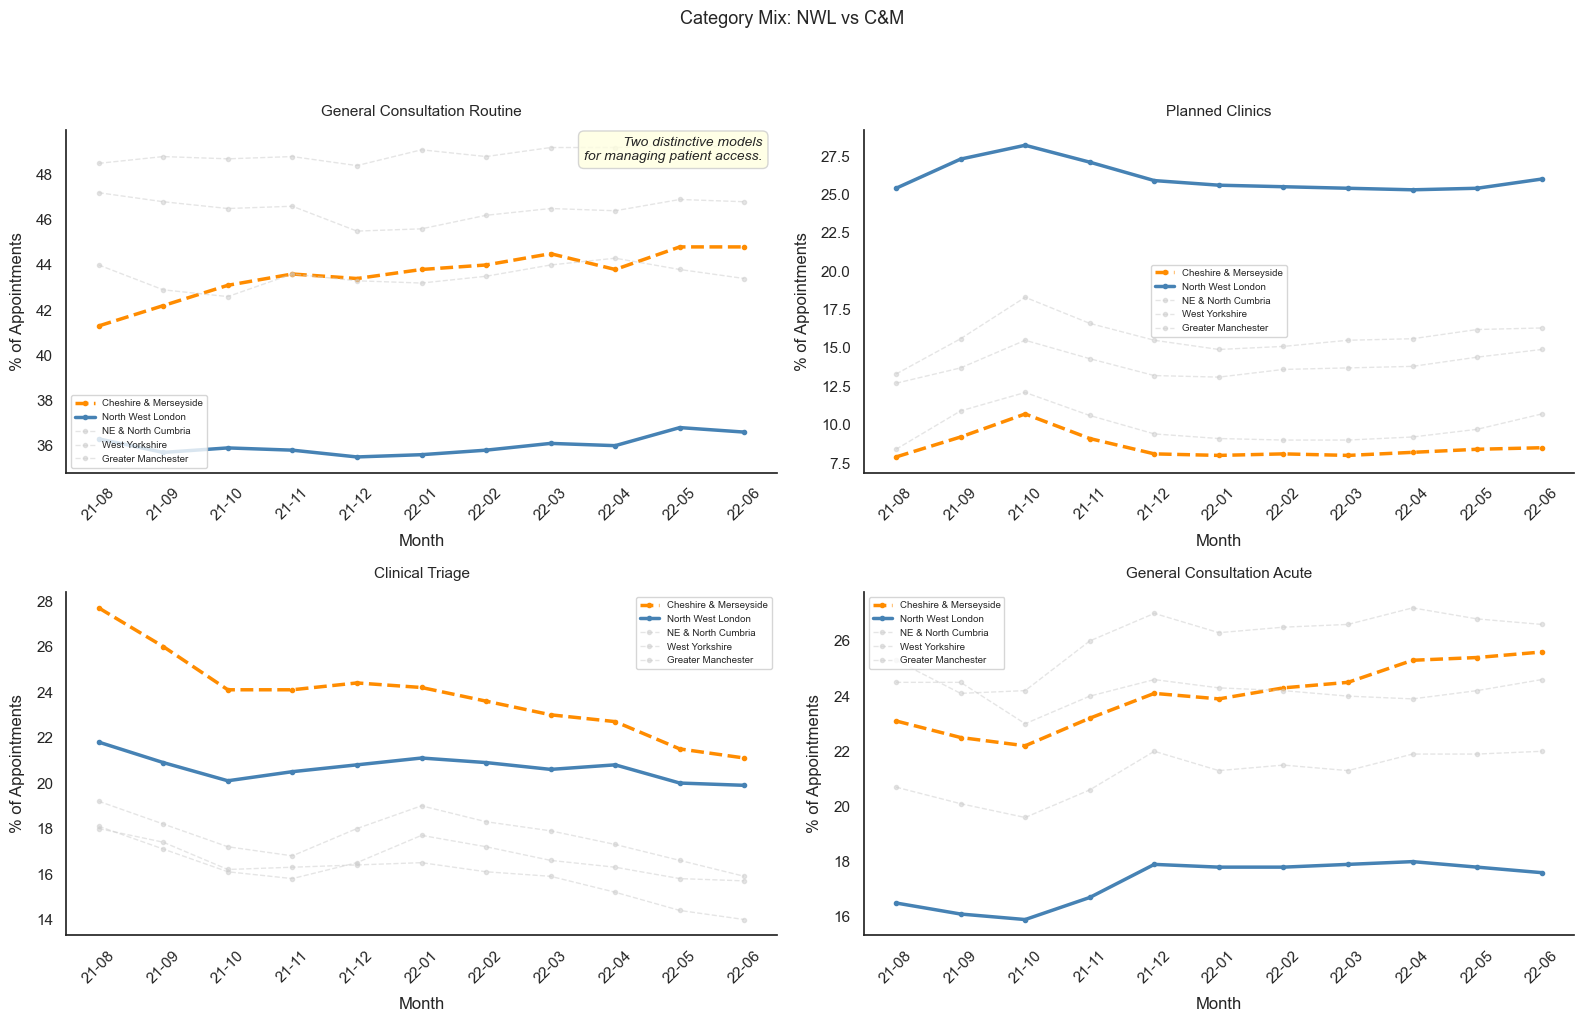

In [213]:
# CHART 5: Two distinctive models of managing patient access

# Filter nc to five ICBs and four key categories
key_cats = [
    'General Consultation Routine',
    'Planned Clinics',
    'Clinical Triage',
    'General Consultation Acute'
]

top5_cat_monthly = nc[
    (nc['icb_ons_code'].isin(top5_icbs.keys())) &
    (nc['national_category'].isin(key_cats))
].groupby(
    ['icb_ons_code', 'appointment_month', 'national_category']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions within each ICB per month
monthly_total = top5_cat_monthly.groupby(
    ['icb_ons_code', 'appointment_month']
)['count_of_appointments'].transform('sum')

top5_cat_monthly['percentage'] = (
    top5_cat_monthly['count_of_appointments'] /
    monthly_total * 100
).round(1)

top5_cat_monthly['icb_name'] = top5_cat_monthly[
    'icb_ons_code'].map(top5_icbs)
top5_cat_monthly['appointment_month'] = top5_cat_monthly[
    'appointment_month'].astype(str)

triage_monthly = top5_cat_monthly[
    top5_cat_monthly['national_category'] == 'Clinical Triage'
].copy()

# Colours — NWL and C&M highlighted, others greyed out
colours = {
    'Cheshire & Merseyside': 'darkorange',
    'North West London': 'steelblue',
    'NE & North Cumbria': '#cccccc',
    'West Yorkshire': '#cccccc',
    'Greater Manchester': '#cccccc'
}

# Line styles and widths
linewidths = {
    'North West London': 2.5,
    'Cheshire & Merseyside': 2.5,
    'NE & North Cumbria': 1.0,
    'West Yorkshire': 1.0,
    'Greater Manchester': 1.0
}

linestyles = {
    'North West London': '-',
    'Cheshire & Merseyside': '--',
    'NE & North Cumbria': '--',
    'West Yorkshire': '--',
    'Greater Manchester': '--'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, category in enumerate(key_cats):
    ax = axes[idx]
    cat_data = top5_cat_monthly[
        top5_cat_monthly['national_category'] == category
    ]

    for icb_name, colour in colours.items():
        subset = cat_data[cat_data['icb_name'] == icb_name]
        lw = linewidths[icb_name]
        ls = linestyles[icb_name]
        alpha = 1.0 if icb_name in [
            'North West London', 'Cheshire & Merseyside'
        ] else 0.5

        ax.plot(subset['appointment_month'],
                subset['percentage'],
                color=colour, linewidth=lw,
                linestyle=ls, alpha=alpha,
                marker='o', markersize=3,
                label=icb_name)

    ax.set_title(category, pad=10, fontsize=11)
    ax.set_xlabel('Month', labelpad=8)
    ax.set_ylabel('% of Appointments', labelpad=8)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(
    [t[2:7] for t in sorted(top5_cat_monthly['appointment_month'].unique())],
    rotation=45
)
    ax.legend(fontsize=7, loc='best')
    sns.despine(ax=ax)

# Key takeaway annotation on first subplot
axes[0].annotate(
    'Two distinctive models\nfor managing patient access.',
    xy=(0.98, 0.98),
    xycoords='axes fraction',
    fontsize=10,
    style='italic',
    va='top',
    ha='right',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow',
              edgecolor='#cccccc',
              alpha=0.8)
)

plt.suptitle('Category Mix: NWL vs C&M\n',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Key Findings

**North West London ICB and Cheshire & Merseyside ICB**

**1. Use of planned clinics and clinical triage**
North West London makes substantially more use of planned clinics than the other four largest ICBs. Cheshire & Merseyside, not NWL, records the highest clinical triage rate. This suggests a structured, triage-first service model that differs fundamentally from its peers. This model appears to free GP capacity for more complex cases while directing routine and minor acute cases through more efficient channels.

**2. Capacity pressure in NWL during October 2021**
The October 2021 capacity pressure in NWL (see Chart 2) is consistent with GP practices working actively through a post-COVID backlog using additional planned clinic sessions. This pattern signals a proactive response and potentially good practice worth investigating further.

**3. Comparing use of clinical triage across ICBs**
Cheshire & Merseyside shows a declining clinical triage proportion alongside persistently high routine GP consultation rates, suggesting triage is functioning primarily as a gateway to GP appointments rather than diverting demand to more appropriate settings. By contrast, NWL maintains a markedly lower routine GP consultation rate alongside a stable triage proportion, consistent with a model in which triage more effectively streams demand toward planned clinics and other settings, reducing overall GP workload. This difference may represent a key operational distinction between the two ICBs.

### Key Recommendations

1. Further investigate NWL's triage and planned clinic model to confirm this as potential best practice, and consider piloting it in another large ICB to relieve capacity pressure.

2. Further investigate the use of clinical triage in Cheshire & Merseyside. Is there scope to make better use of planned clinics to divert demand away from routine GP consultations?


---
# 5. Lead times: what the access model costs patients

If NWL's model manages GP workload more efficiently, the question is what
patients give up in return.

## 5.1 Trends in time between booking and appointment

**Analytical question:** Are there any trends in time between booking and appointment?

In [160]:
# Q5: Time between booking and appointment
print(ar_2021['time_between_book_and_appointment'].unique())

['1 Day' '15  to 21 Days' '2 to 7 Days' '22  to 28 Days' '8  to 14 Days'
 'More than 28 Days' 'Same Day' 'Unknown / Data Quality']


**Observations:**
The bands are of unequal length and stored as strings, so not in the correct order.

In [161]:
# Define correct logical order
lead_time_order = [
    'Same Day',
    '1 Day',
    '2 to 7 Days',
    '8 to 14 Days',
    '15 to 21 Days',
    '22 to 28 Days',
    'More than 28 Days',
    'Unknown / Data Quality'
]

# Convert to ordered categorical
ar_2021['time_between_book_and_appointment'] = pd.Categorical(
    ar_2021['time_between_book_and_appointment'],
    categories=lead_time_order,
    ordered=True
)

# Verify ordering
print(ar_2021['time_between_book_and_appointment'].value_counts().sort_index())

time_between_book_and_appointment
Same Day                  34992
1 Day                     32836
2 to 7 Days               34257
8 to 14 Days                  0
15 to 21 Days                 0
22 to 28 Days                 0
More than 28 Days         24674
Unknown / Data Quality    11569
Name: count, dtype: int64


**Observation:** 3 of the bands have no listed appointments. Check this.

In [162]:
# Check exact string values including spaces
for val in ar_2021['time_between_book_and_appointment'].unique():
    print(repr(val))

'1 Day'
nan
'2 to 7 Days'
'More than 28 Days'
'Same Day'
'Unknown / Data Quality'


**Observation:** The three bands showing 0 have no recorded data in this dataset. This may be a data quality issue as noted in the metadata.

In [163]:
# Corrected order based on actual values in data
lead_time_order = [
    'Same Day',
    '1 Day',
    '2 to 7 Days',
    'More than 28 Days',
    'Unknown / Data Quality'
]

ar_2021['time_between_book_and_appointment'] = pd.Categorical(
    ar_2021['time_between_book_and_appointment'],
    categories=lead_time_order,
    ordered=True
)

# Drop nulls for analysis
ar_lead = ar_2021.dropna(
    subset=['time_between_book_and_appointment'])

print(ar_lead['time_between_book_and_appointment']
      .value_counts().sort_index())
print(f"\nRows dropped (null lead time): "
      f"{len(ar_2021) - len(ar_lead)}")

time_between_book_and_appointment
Same Day                  34992
1 Day                     32836
2 to 7 Days               34257
More than 28 Days         24674
Unknown / Data Quality    11569
Name: count, dtype: int64

Rows dropped (null lead time): 85090


**Observation:** 85,000 rows of aggregated appointments have no lead time.

In [164]:
# Quantify appointments lost with null lead times
total_appts = ar_2021['count_of_appointments'].sum()
kept_appts = ar_lead['count_of_appointments'].sum()
lost_appts = total_appts - kept_appts
lost_pct = (lost_appts / total_appts * 100).round(1)

print(f"Total appointments (ar_2021): {total_appts:,}")
print(f"Appointments with lead time data: {kept_appts:,}")
print(f"Appointments lost (null lead time): {lost_appts:,}")
print(f"Percentage lost: {lost_pct}%")

Total appointments (ar_2021): 296,046,770
Appointments with lead time data: 227,654,807
Appointments lost (null lead time): 68,391,963
Percentage lost: 23.1%


In [165]:
# Check exact string values including spaces
for val in ar_2021['time_between_book_and_appointment'].unique():
    print(repr(val))

'1 Day'
nan
'2 to 7 Days'
'More than 28 Days'
'Same Day'
'Unknown / Data Quality'


**Observation:** Almost a quarter of all appointments are missing. Check what types of appointments these are.

In [166]:
# Check if null lead times are evenly distributed
# across appointment modes
null_by_mode = ar_2021[
    ar_2021['time_between_book_and_appointment'].isna()
].groupby('appointment_mode')[
    'count_of_appointments'].sum().reset_index()

total_by_mode = ar_2021.groupby(
    'appointment_mode')[
    'count_of_appointments'].sum().reset_index()

null_by_mode = null_by_mode.merge(
    total_by_mode, on='appointment_mode',
    suffixes=('_null', '_total'))

null_by_mode['null_pct'] = (
    null_by_mode['count_of_appointments_null'] /
    null_by_mode['count_of_appointments_total'] * 100
).round(1)

print(null_by_mode[['appointment_mode',
                     'count_of_appointments_null',
                     'count_of_appointments_total',
                     'null_pct']].sort_values(
    'null_pct', ascending=False))

  appointment_mode  count_of_appointments_null  count_of_appointments_total  \
0     Face-to-Face                    51074195                    183503587   
4     Video/Online                      383501                      1543497   
3          Unknown                     1610461                      8733661   
2        Telephone                    15139814                    100274881   
1       Home Visit                      183992                      1991144   

   null_pct  
0      27.8  
4      24.8  
3      18.4  
2      15.1  
1       9.2  


The lead time analysis is materially compromised by data quality issues. 

23.1% of appointments have null lead times, and this missing data is not randomly distributed — Video/Online appointments and Unknown mode appointments are disproportionately represented. Given that Video/Online appointments likely cluster in shorter lead time bands, the remaining data probably understates the proportion of same-day and next-day appointments, making the system appear marginally less responsive than it actually is. 

Face to face appointments have both the highest volumes and the highest null rates. These are likely to include both urgent and planned appointments.

Lead time findings should therefore be treated as indicative only and interpreted with caution.

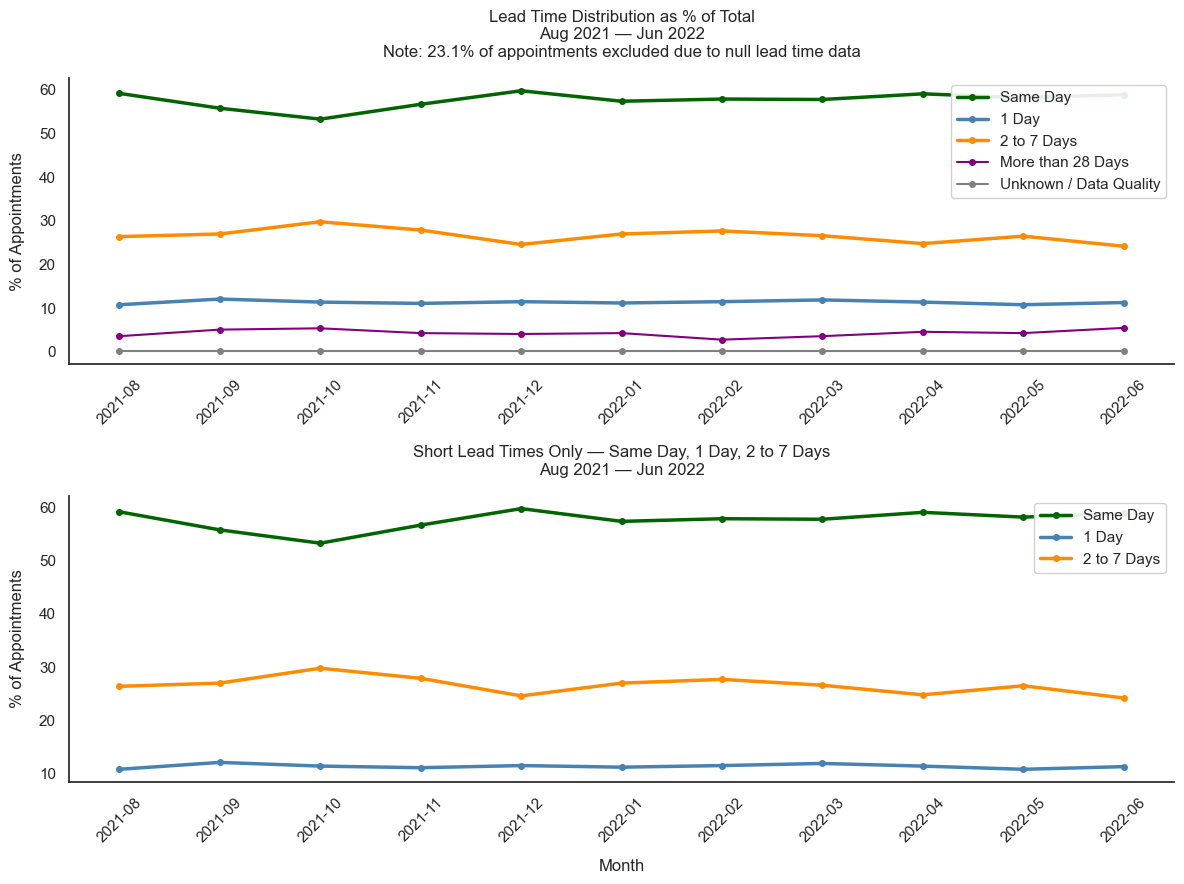

In [167]:
# Q5: Lead time distribution over time
ar_lead_monthly = ar_lead.groupby(
    ['appointment_month', 
     'time_between_book_and_appointment']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions
ar_lead_monthly_total = ar_lead_monthly.groupby(
    'appointment_month')['count_of_appointments'].transform('sum')
ar_lead_monthly['proportion'] = (
    ar_lead_monthly['count_of_appointments'] /
    ar_lead_monthly_total * 100
).round(1)

# Sort months correctly
ar_lead_monthly['appointment_month_dt'] = pd.to_datetime(
    ar_lead_monthly['appointment_month'])
ar_lead_monthly = ar_lead_monthly.sort_values(
    'appointment_month_dt')
ar_lead_monthly['appointment_month'] = ar_lead_monthly[
    'appointment_month_dt'].dt.strftime('%Y-%m')

# Plot proportions by lead time band
lead_colours = {
    'Same Day': 'darkgreen',
    '1 Day': 'steelblue',
    '2 to 7 Days': 'darkorange',
    'More than 28 Days': 'purple',
    'Unknown / Data Quality': 'grey'
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# Top panel: proportions over time
for band, colour in lead_colours.items():
    subset = ar_lead_monthly[
        ar_lead_monthly[
            'time_between_book_and_appointment'
        ] == band
    ].sort_values('appointment_month_dt')
    
    lw = 2.5 if band in ['Same Day', '1 Day',
                          '2 to 7 Days'] else 1.5
    ax1.plot(subset['appointment_month'],
             subset['proportion'],
             color=colour, linewidth=lw,
             marker='o', markersize=4,
             label=band)

ax1.set_title('Lead Time Distribution as % of Total\n'
              'Aug 2021 — Jun 2022\n'
              'Note: 23.1% of appointments excluded '
              'due to null lead time data',
              pad=15)
ax1.set_xlabel('')
ax1.set_ylabel('% of Appointments', labelpad=10)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper right', framealpha=0.9)
sns.despine(ax=ax1)

# Bottom panel: short lead times only (most clinically relevant)
short_bands = ['Same Day', '1 Day', '2 to 7 Days']

for band, colour in lead_colours.items():
    if band not in short_bands:
        continue
    subset = ar_lead_monthly[
        ar_lead_monthly[
            'time_between_book_and_appointment'
        ] == band
    ].sort_values('appointment_month_dt')
    
    ax2.plot(subset['appointment_month'],
             subset['proportion'],
             color=colour, linewidth=2.5,
             marker='o', markersize=4,
             label=band)

ax2.set_title('Short Lead Times Only — Same Day, 1 Day, '
              '2 to 7 Days\nAug 2021 — Jun 2022',
              pad=15)
ax2.set_xlabel('Month', labelpad=10)
ax2.set_ylabel('% of Appointments', labelpad=10)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right', framealpha=0.9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

**Observations:**

1. Lead times of more than 28 days are of a different nature to those for patients seen within a week. The former are planned and the latter are a measure of responsiveness to demand for diagnosis and immediate treatment. In order to focus on the latter, the second chart looks only at lead times of same day, 1 day and 2 - 7 days. This merits analysis at a more granular level.

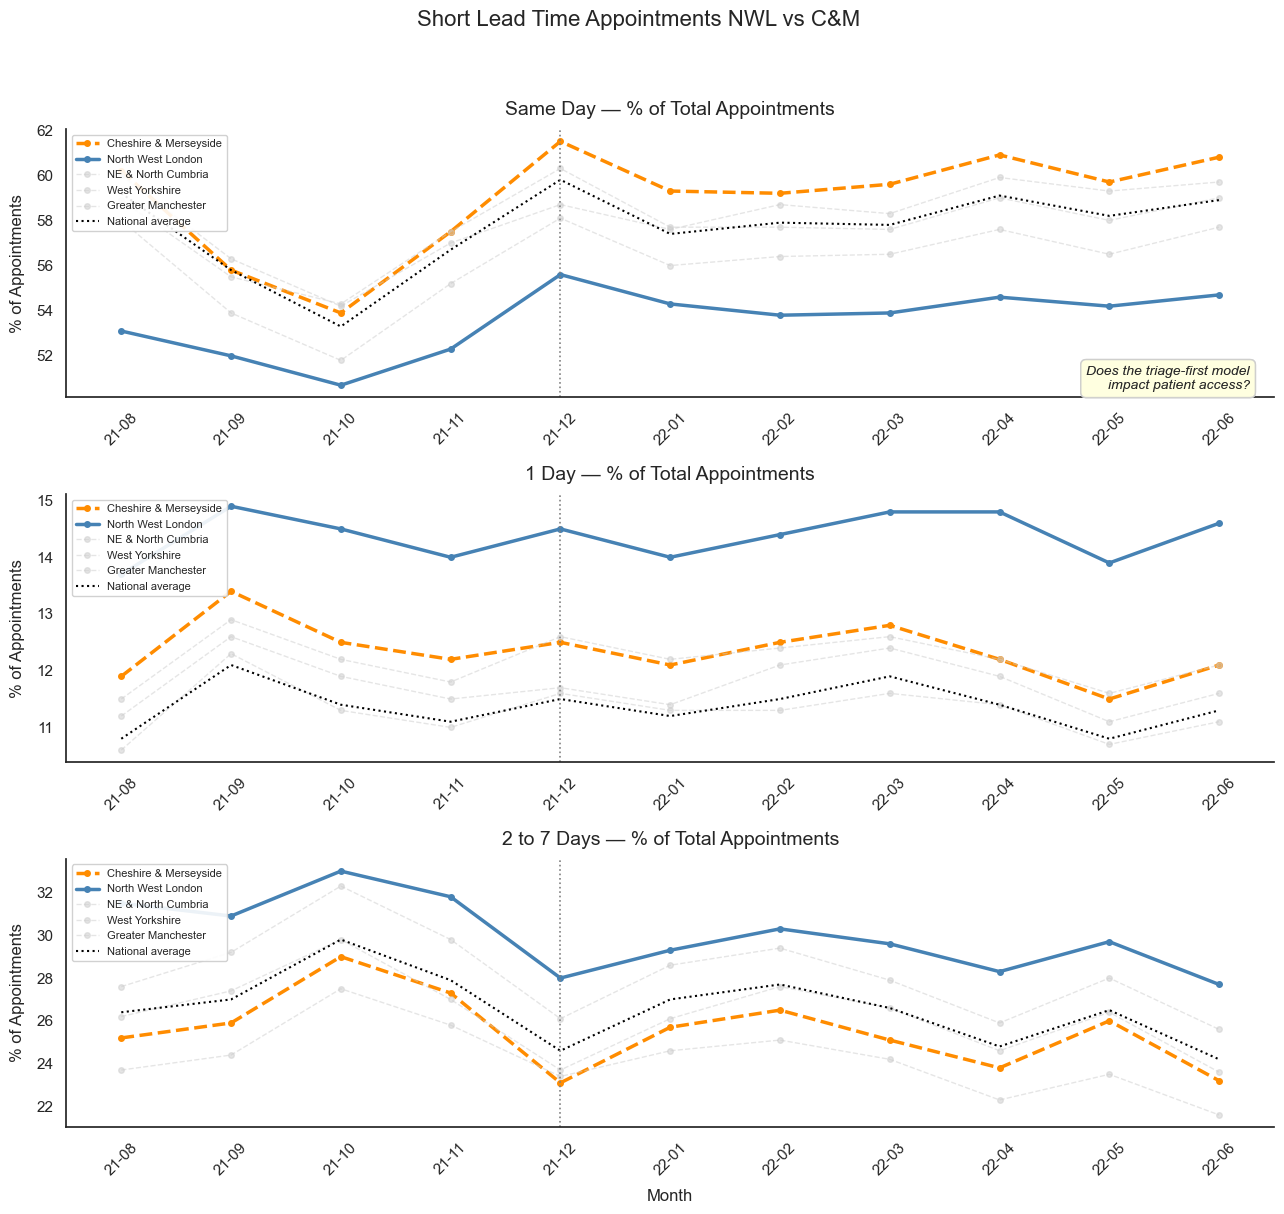

In [214]:
# Chart 6: Expressed Unmet Demand in NWL vs C&M
# Lead time breakdown, five largest ICBs
# How do the largest ICBs differ in their ability to manage lead in times
# for unplanned appointments?

# Lead time breakdown for five large ICBs
top5_lead = ar_lead[
    ar_lead['icb_ons_code'].isin(top5_icbs.keys())
].groupby(
    ['icb_ons_code', 'appointment_month',
     'time_between_book_and_appointment']
)['count_of_appointments'].sum().reset_index()

# Calculate proportions within each ICB per month
top5_lead_total = top5_lead.groupby(
    ['icb_ons_code', 'appointment_month']
)['count_of_appointments'].transform('sum')

top5_lead['proportion'] = (
    top5_lead['count_of_appointments'] /
    top5_lead_total * 100
).round(1)

top5_lead['icb_name'] = top5_lead['icb_ons_code'].map(top5_icbs)
top5_lead['appointment_month_dt'] = pd.to_datetime(
    top5_lead['appointment_month']
)
top5_lead = top5_lead.sort_values('appointment_month_dt')
top5_lead['appointment_month'] = (
    top5_lead['appointment_month_dt'].dt.strftime('%y-%m')
)

# Colours — NWL and C&M highlighted, others greyed out
icb_colours = {
    'Cheshire & Merseyside': 'darkorange',
    'North West London': 'steelblue',
    'NE & North Cumbria': '#cccccc',
    'West Yorkshire': '#cccccc',
    'Greater Manchester': '#cccccc'
}

icb_linewidths = {
    'North West London': 2.5,
    'Cheshire & Merseyside': 2.5,
    'NE & North Cumbria': 1.0,
    'West Yorkshire': 1.0,
    'Greater Manchester': 1.0
}

icb_alphas = {
    'North West London': 1.0,
    'Cheshire & Merseyside': 1.0,
    'NE & North Cumbria': 0.5,
    'West Yorkshire': 0.5,
    'Greater Manchester': 0.5
}

icb_linestyles = {
    'North West London': '-',
    'Cheshire & Merseyside': '--',
    'NE & North Cumbria': '--',
    'West Yorkshire': '--',
    'Greater Manchester': '--'
}

# Plot short lead times only
short_bands = ['Same Day', '1 Day', '2 to 7 Days']
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for idx, band in enumerate(short_bands):
    ax = axes[idx]
    band_data = top5_lead[
        top5_lead['time_between_book_and_appointment'] == band
    ]

    for name in top5_icbs.values():
        subset = band_data[
            band_data['icb_name'] == name
        ].sort_values('appointment_month_dt')

        ax.plot(subset['appointment_month'],
                subset['proportion'],
                color=icb_colours[name],
                linewidth=icb_linewidths[name],
                linestyle=icb_linestyles[name],
                alpha=icb_alphas[name],
                marker='o', markersize=4,
                label=name)

    # National average for comparison
    national_band = ar_lead_monthly[
        ar_lead_monthly['time_between_book_and_appointment'] == band
    ].sort_values('appointment_month_dt')

    # Format national average month to match
    national_band = national_band.copy()
    national_band['appointment_month'] = pd.to_datetime(
        national_band['appointment_month']
    ).dt.strftime('%y-%m')

    ax.plot(national_band['appointment_month'],
            national_band['proportion'],
            color='black', linewidth=1.5,
            linestyle=':', marker='',
            label='National average')

    # December inflection marker
    ax.axvline(x='21-12', color='grey',
               linestyle=':', linewidth=1.2)

    ax.set_title(f'{band} — % of Total Appointments',
                 pad=10, fontsize=14)
    ax.set_xlabel('Month' if idx == 2 else '', labelpad=8)
    ax.set_ylabel('% of Appointments', labelpad=8)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.9)
    sns.despine(ax=ax)

# Key takeaway annotation on first subplot
    axes[0].annotate(
    'Does the triage-first model\nimpact patient access?',
    xy=(0.98, 0.02),
    xycoords='axes fraction',
    fontsize=10,
    style='italic',
    va='bottom',
    ha='right',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow',
              edgecolor='#cccccc',
              alpha=0.8)
)

plt.suptitle(
    'Short Lead Time Appointments NWL vs C&M \n',
    fontsize=16, y=1.01
)
plt.tight_layout()
plt.show()


### Key Findings from Chart 6

NWL has the lowest percentages of same day appointments and the highest percentages on both 1 day and 2-7 day lead in times. NWL's lead time profile is consistent with a triage-first model that prioritises the efficient allocation of planned capacity over immediate access. This has been shown to help manage GP workload, but it raises important questions about whether patients requiring same-day care are being seen with sufficient urgency. Note: There are known data quality issues with this dataset as recorded above. Notably, the missing data is not randomly distributed. The metadata confirms that Video/Online and Unknown mode appointments are disproportionately affected, likely understating same-day appointment proportions and making the system appear marginally less responsive than it actually is. NWL's lead time profile should therefore be interpreted conservatively.


### Recommendation update
Although previous analysis suggested efficiency gains through the NWL triage model, the above charts provide a different lens through which to review this, highlighting an inherent delay in initial appointments, with same-day access sitting around 6 percentage points below the other largest ICBs, and a key warning about high levels of expressed unmet demand.

Further investigation of NWL's triage outcomes is required before recommending their triage-first model for wider adoption. This investigation should focus on both clinical safety metrics and patient experience. The potential efficiency gain of extending their model is substantial but both the clinical risks and the impact on patients of having limited access to same day appointments must be measured. For example, through a comparison across ICBs of attendance rates at hospital emergency departments (for same day medical attention)


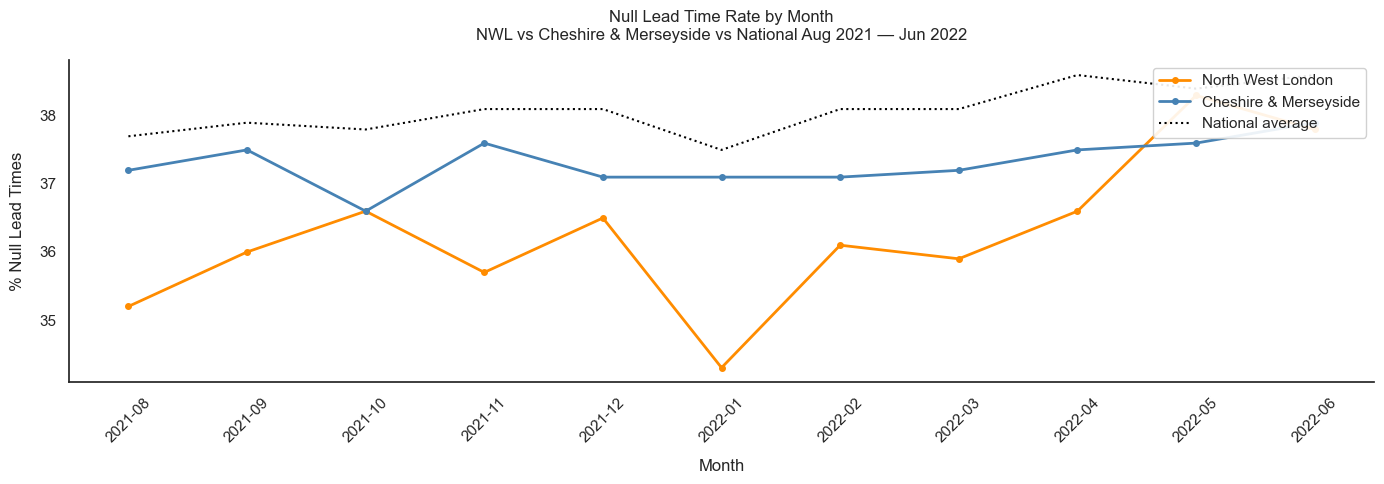

In [215]:
# CHART 6b: Lead Time Data Quality Validation

# Compare null lead time rates: NWL, C&M and National
# to assess whether lead time findings are affected by 
# differential data quality

# Define ICBs to compare
icbs_to_compare = {
    'E54000027': 'North West London',
    'E54000008': 'Cheshire & Merseyside'
}

# Calculate null lead time rate by ICB and month
icb_null = ar_2021[
    ar_2021['icb_ons_code'].isin(icbs_to_compare.keys())
].copy()

icb_null['is_null'] = icb_null[
    'time_between_book_and_appointment'].isna()

icb_monthly_null = icb_null.groupby(
    ['icb_ons_code', 'appointment_month']
).agg(
    null_count=('is_null', 'sum'),
    total_count=('is_null', 'count')
).reset_index()

icb_monthly_null['null_pct'] = (
    icb_monthly_null['null_count'] /
    icb_monthly_null['total_count'] * 100
).round(1)

icb_monthly_null['icb_name'] = icb_monthly_null[
    'icb_ons_code'].map(icbs_to_compare)

icb_monthly_null['appointment_month'] = (
    icb_monthly_null['appointment_month'].astype(str)
)

# Calculate national null rate by month
national_null = ar_2021.copy()
national_null['is_null'] = national_null[
    'time_between_book_and_appointment'].isna()

national_monthly_null = national_null.groupby(
    'appointment_month'
).agg(
    null_count=('is_null', 'sum'),
    total_count=('is_null', 'count')
).reset_index()

national_monthly_null['null_pct'] = (
    national_monthly_null['null_count'] /
    national_monthly_null['total_count'] * 100
).round(1)

national_monthly_null['appointment_month'] = (
    national_monthly_null['appointment_month'].astype(str)
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

colours = {
    'North West London': 'darkorange',
    'Cheshire & Merseyside': 'steelblue'
}

for icb_name, colour in colours.items():
    subset = icb_monthly_null[
        icb_monthly_null['icb_name'] == icb_name
    ]
    ax.plot(subset['appointment_month'],
            subset['null_pct'],
            color=colour, linewidth=2,
            marker='o', markersize=4,
            label=icb_name)

# National average
ax.plot(national_monthly_null['appointment_month'],
        national_monthly_null['null_pct'],
        color='black', linewidth=1.5,
        linestyle=':', marker='',
        label='National average')

ax.set_title('Null Lead Time Rate by Month\n'
             'NWL vs Cheshire & Merseyside vs National '
             'Aug 2021 — Jun 2022',
             pad=15)
ax.set_xlabel('Month', labelpad=10)
ax.set_ylabel('% Null Lead Times', labelpad=10)
plt.xticks(rotation=45)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
sns.despine()
plt.show()

**Analytical question:** Are NWL's lead time findings an artefact 
of poor data recording?

**Key Finding:** NWL consistently records the lowest null lead time 
rate of the three, and both NWL and C&M record lead times more 
reliably than the national average. The same-day access gap identified 
in Chart 6 cannot be attributed to data quality differences and should 
be treated as a genuine finding.

---
# 6. Summary and recommendations

> ## Summary and Recommendations
>
> ## Context 
This analysis uses appointment records from GP surgeries across England to explore patterns and trends in demand and capacity, and to gain initial insight into how different parts of the NHS are responding to pressure on services. Three analytical questions frame the investigation: whether there has been adequate capacity, how GP practices are responding to demand pressure, and what external data can tell us that appointment records cannot. It should be noted at the outset that this analysis covers a period when the entire health system was in the immediate aftermath of an unprecedented global demand on healthcare services. Additionally, the underlying data is incomplete in several respects. For both reasons, all findings should be treated as indicative only.

## Key Finding 1: The NHS is operating under severe capacity pressure
Based on a 5-day working week (empirically validated) along with the NHS published benchmark of 1.2 million daily appointments, the NHS across England operated above 100% theoretical maximum capacity for 7 of the 11 months in the analysis period. Capacity pressures peak in October, November and March, with relative relief in December and April. 
This finding is sensitive to the measurement assumptions used. An initial baseline dividing appointments by 30 calendar days per month understates pressure by around 20 percentage points. Day-of-week analysis established that 97.9% of appointments take place between Monday and Friday, with Saturday appointments predominantly comprising planned procedures rather than available GP capacity for unplanned demand.

## Key Finding 2: A unique pattern emerges in North West London
The five largest Integrated Care Boards by appointment volume were identified and the national benchmark of 1.2 million daily appointments was apportioned. This may not fully reflect actual resource allocation (see note below) but allows us to explore patterns of demand at a more granular level. North West London (NWL) follows a distinctly different utilisation trajectory, operating at lower capacity than its peers in the early months of the period before converging and then diverging again. Six hypotheses were tested to explain this divergence, including DNA rates, population size, and demographic factors, before the key driver was identified in the category mix analysis.

**Note on the limitations of capacity measures in Chart 4**

At national level, the 1.2M benchmark provides a robust measure of system-wide pressure. At ICB level, proportional apportionment introduces circularity: ICBs with suppressed demand receive a lower benchmark, potentially overstating true capacity pressure. Normalisation by registered patient population (possible only at sub-ICB level) addresses this, providing a more reliable basis for comparison and explaining why utilisation pressure, while still evident, appears less acute under this more conservative measure.

## Key Finding 3: Two distinctive models of managing patient access
Comparison of appointment category mix across the five largest ICBs reveals two structurally different approaches:
North West London operates a triage-first, planned capacity model. NWL has the highest use of planned clinics and relatively high clinical triage, with correspondingly low rates of general consultation (both routine and acute). This model frees valuable GP resource and initially appears to represent good practice.
Cheshire & Merseyside (C&M) has the highest clinical triage rate of all five ICBs, though this has been falling steadily throughout the period. Despite high triage rates, C&M consistently records the highest rates of routine general consultation. Triage in C&M functions simply as an appointment prioritisation tool: all roads lead to a GP.
These two ICBs are broadly comparable in terms of registered patient population and overall appointment volumes, making them a meaningful basis for comparison.

## Key Finding 4: The triage-first model restricts patient access
Analysis of short lead time appointments reveals a striking paradox: NWL, whose triage-first model appears efficient from a capacity perspective, consistently records the lowest same-day appointment rate of all five ICBs. C&M, whose triage model routes patients directly to GPs, consistently records the highest.
This finding has been validated for data quality: NWL's null lead time rate is the lowest of the three ICBs compared, confirming that the same-day gap is not an artefact of poor data recording.
The paradox is further compounded by the demographic context. Despite having slightly fewer registered patients than C&M, NWL sees approximately 100,000 fewer appointments per month. In a diverse, inner-city population with high levels of deprivation, restricted same-day access carries particular risk. Patients unable to secure timely appointments may attend A&E unnecessarily, delay care until conditions worsen, or simply go without - a risk that falls disproportionately on the most vulnerable.
The shift toward Other Practice Staff appointments over the period is consistent with implementation of the Additional Roles Reimbursement Scheme (ARRS), suggesting workforce diversification is underway. However, classification limitations in the data limit conclusions about which roles are absorbing demand.

## Key Finding 5: External data sources are of limited value
Twitter data was explored and excluded. The dataset is dominated by the #healthcare hashtag but is geographically widespread, with many comments originating from USA-based users discussing a different healthcare system. Even potentially relevant hashtags such as #covid and #nursing contain insufficient NHS England-specific content to be analytically useful.
A structured patient survey would provide far more reliable external insight. Distributed digitally to all registered patients (with paper copies for non-digital patients), questions could cover timeliness of access, experience of triage, reasons for missed appointments, and experience of non-GP clinical staff. With AI-assisted sentiment analysis now feasible at scale, responses could be processed efficiently and linked to ICB and sub-ICB level appointment data to provide a richer picture of patient experience than social media data can offer.

## Recommendations

### 1. Investigate NWL’s triage outcomes before recommending wider adoption
NWL's triage-first model shows potential efficiency gains but demonstrably restricts same-day access. Further investigation should focus on clinical safety metrics, particularly A&E attendance rates for NWL vs C&M as a proxy for unmet same-day GP demand. It should also ideally include a comparison of patient outcomes: are patients denied same-day appointments at higher risk? Only with this evidence can a recommendation on wider adoption be made responsibly.

### 2. Commission a Patient Experience survey
Appointment records measure activity but cannot capture patient experience, unmet demand, or reasons for DNA. A targeted patient survey across NWL and C&M would directly complement this analysis, providing qualitative insight into the access and triage experience from the patient perspective.

### 3. Introduce more granular lead-time bands

The current bands record 2 to 7 days as a single category, so a 2-day wait and a 7-day wait are indistinguishable in the published data. Splitting this into Same Day, 1 Day, 2 Days, 3-4 Days and 5-7 Days would allow short waits for unplanned illness to be monitored for clinical safety, which matters most where a triage-first model demonstrably restricts same-day access, as NWL's does.



### 4. Commission an initiative to improve data quality at Practice level

A recurring theme across this analysis is the impact of data quality on the reliability of findings. Improving data quality at practice level is a prerequisite for effective capacity planning. With improved data, commissioners would be better positioned to:
•	Identify expressed unmet demand and quantify the gap between demand and capacity at sub-ICB level
•	Analyse variation by day of week to inform appointment scheduling — for example redistributing planned appointments away from Mondays, when acute demand peaks
•	Track repeated DNA patterns at patient level to distinguish wasted capacity from genuine access barriers

Better data does not increase capacity, but it enables the same capacity to be used more effectively,  a substantial opportunity in a system consistently operating at or beyond capacity.
